# โครงการวิเคราะห์ข้อมูลเพื่อกู้คืนรายได้: The Azure Stay Hotel
**วิชา:** Data Analytics and Business Intelligence  
**สมาชิก:**
1. นายพชรพล เพ็ชรชููชาติ 66102010146
2. นายเอกภพ อุ่นมา 66102010158
3. นายกรวิชญ์ ชูน้อย 66102010564

---

## Background and Pain points
โรงแรมขนาดกลางที่บริหารงานอิสระชื่อ "The Azure Stay" แม้ว่าตัวโรงแรมจะสวยงามและมีศักยภาพ แต่ผลกำไรกลับหยุดนิ่งไม่เติบโต

**ปัญหาหลัก:** การรั่วไหลของรายได้จากการยกเลิกจองและการไม่เข้าพัก (Revenue Leakage - Cancellations & No-Shows) ตารางการจองห้องพักของคุณดูเหมือนจะถูกจองเต็มล่วงหน้าถึง 2 สัปดาห์ แต่เมื่อถึงวันเข้าพักจริง กลับกลายเป็นว่ามีห้องว่างเหลืออยู่จำนวนมาก สาเหตุมาจากการยกเลิกกะทันหัน (Last-minute cancellations) และลูกค้าที่จองไว้แต่ไม่มาปรากฏตัว (No-shows) ทำให้คุณไม่สามารถนำห้องเหล่านั้นไปขายต่อให้ลูกค้าคนอื่นได้ทันเวลา

**ผลกระทบคือ:**
- เสียลูกค้าตัวจริง: ปฏิเสธคนที่พร้อมจ่าย เพราะระบบโชว์ว่าห้องเต็มไปแล้ว (Opportunity Cost)
- เสียต้นทุนฟรี: พนักงานและวัตถุดิบถูกเตรียมไว้ล่วงหน้า เกิดเป็นต้นทุนจม (Sunk Cost)

**เป้าหมาย:** ลดการสูญเสียรายได้ที่เกิดจากความต้องการเข้าพักแบบปลอมๆ (Fake demand) หรือความต้องการที่ไม่แน่นอน (Unstable demand)

---

## Smart Objectives
เพื่อกู้คืนรายได้ที่สูญเสียไป อย่างน้อย 15% ภายในระยะเวลา 2 ไตรมาสเมื่อเทียบกับไตรมาสก่อนหน้า
โดยอาศัยการวิเคราะห์ข้อมูลพฤติกรรมการยกเลิกการจอง เพื่อช่วยให้โรงแรมสามารถคัดเลือกลูกค้าที่มีความน่าเชื่อถือได้อย่างเหมาะสม


# Preparation

In [1]:
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

In [2]:
!pip install -q adjustText

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib as mpl
import matplotlib.font_manager as fm
from google.colab import drive
import calendar

In [4]:
# ==============================================================================
# GLOBAL STYLING & CONFIGURATION (Single Source of Truth - Standard Semantic)
# ==============================================================================

# 1. กำหนด Color Palette มาตรฐาน เขียว-เหลือง-แดง (High Contrast)
# ------------------------------------------------------------------------------
C_BLUE  = '#28A745'   # Success / Checked-in (เขียวเข้มอ่านง่าย)
C_PINK = '#FFC107'   # Warning / Comparison (เหลืองมาตรฐาน)
C_RED    = '#DC3545'   # Danger / Cancelled / No-show (แดงชัดเจน)

my_palette = [C_BLUE, C_PINK, C_RED]

# 2. ตั้งค่าฟอนต์ภาษาไทย (TH Sarabun New)
# ------------------------------------------------------------------------------
font_path = 'thsarabunnew-webfont.ttf'
try:
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'TH Sarabun New'
    print(f"ติดตั้งฟอนต์ TH Sarabun New เรียบร้อยแล้ว")
except:
    print(f"คำเตือน: ไม่พบไฟล์ฟอนต์ที่ {font_path}")

# 3. ตั้งค่า Matplotlib & Seaborn Global Parameters
# ------------------------------------------------------------------------------
sns.set_theme(style="whitegrid", rc={
    "font.family": "TH Sarabun New",
    "axes.unicode_minus": False
})

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,        # หัวข้อใหญ่ ชัดเจน
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (12, 7),
    'lines.linewidth': 3,
    'lines.markersize': 10,
    'axes.axisbelow': True,      # เส้น Grid มุดหลังแท่งกราฟเสมอ
    'grid.alpha': 0.2,           # เส้น Grid จางๆ ไม่กวนสายตา
    'grid.linestyle': '--'       # เส้น Grid แบบประดู Professional
})

# บังคับใช้ Palette มาตรฐานเป็นค่าเริ่มต้น
sns.set_palette(my_palette)

# 4. ตั้งค่าสำหรับ Pie/Donut Chart และ Pandas Display
# ------------------------------------------------------------------------------
PIE_PROPS = {
    'autopct': '%1.2f%%',
    'pctdistance': 0.82,
    'startangle': 140,
    'textprops': {
        'fontsize': 14,
        'weight': 'bold',
        'color': 'black'        # สีดำชัดเจนบนพื้นสีที่อิ่มตัวขึ้น
    }
}

DONUT_RADIUS = 0.70

pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format

print("Global Configuration: STANDARD SEMANTIC THEME READY")

ติดตั้งฟอนต์ TH Sarabun New เรียบร้อยแล้ว
Global Configuration: STANDARD SEMANTIC THEME READY


## โครงสร้างการคำนวณและเกณฑ์การวิเคราะห์ (Global Configuration)
เพื่อให้การวิเคราะห์ทั้ง 8 สมมติฐานมีความสอดคล้องและแม่นยำ เราได้กำหนด "จุดอ้างอิงเดียว" สำหรับสูตรและเกณฑ์การแบ่งกลุ่มไว้ดังนี้:

### 1. สูตรการคำนวณรายได้ (Revenue Metrics)
- **Revenue Loss:** รายได้สุทธิที่หายไป (ค่าห้อง - ค่าปรับที่เก็บได้)
- **Recovery Window:** ระยะเวลาระหว่างการยกเลิกจนถึงวันเข้าพักจริง เพื่อประเมินโอกาสในการขายห้องใหม่ (Resell)
- **True Expected Loss:** มูลค่าความเสียหายที่แท้จริง โดยการนำ Revenue Loss มาคูณกับน้ำหนักความเสี่ยง (Risk Multiplier) ตามความยากง่ายในการขายห้องใหม่

### 2. เกณฑ์การแบ่งกลุ่มความเสี่ยง (Segmentation Bins)
- **Lead Time Group:** แบ่งตามระยะเวลาจองล่วงหน้า (กระชั้นชิด, ระยะกลาง, ล่วงหน้านาน)
- **Resell Window (DBA):** แบ่งกลุ่มตามวันที่ลูกค้ากดยกเลิกจริง เพื่อดูความวิกฤตของการขายห้องใหม่
- **Risk Multipliers:** น้ำหนักความเสียหาย (1.0 = เสียหาย 100%, 0.1 = เสียหายแค่ 10% เพราะขายต่อได้ชัวร์)

In [24]:
# ==============================================================================
# 1-3. เชื่อมต่อและโหลดข้อมูล
# ==============================================================================
drive.mount('/content/drive') # เปิดใช้งานหากรันใน Colab

base_path = '/content/drive/My Drive/CP372/Dataset/'

fact = pd.read_csv(base_path + 'fact_bookings.csv')
dim_chan = pd.read_csv(base_path + 'dim_channels.csv')
dim_pol = pd.read_csv(base_path + 'dim_policies.csv')
dim_guest = pd.read_csv(base_path + 'dim_guests.csv')
dim_rt = pd.read_csv(base_path + 'dim_roomtype.csv')
dim_rate = pd.read_csv(base_path + 'dim_rate_codes.csv')
dim_calendar = pd.read_csv(base_path + 'dim_calendar.csv')

# ==============================================================================
# 4. การเตรียมข้อมูลวันที่ (Preprocessing)
# ==============================================================================
date_cols = ['booking_date', 'check_in_date', 'check_out_date', 'cancellation_date']
for col in date_cols:
    fact[col] = pd.to_datetime(fact[col])

dim_calendar['date_key'] = pd.to_datetime(dim_calendar['date_key'])
fact['year_month'] = fact['check_in_date'].dt.strftime('%Y-%m')

# ==============================================================================
# 5. สร้าง Measures สำคัญ (FIXED: ป้องกันหักลบซ้ำซ้อน)
# ==============================================================================
# ใช้ .max(axis=1) ป้องกัน PMS ลงบัญชีเบิ้ล (Double Entry)
fact['revenue_loss'] = fact['gross_revenue'] - fact[['gross_room_revenue', 'penalty_charged']].fillna(0).max(axis=1)

# [เพิ่มความรัดกุม]: บังคับให้กลุ่ม Checked-In ไม่มียอด Revenue Loss (กันยอดค่าอาหาร/สปาโผล่มาเป็น Loss)
if 'status' in fact.columns:
    fact.loc[fact['status'] == 'Checked-In', 'revenue_loss'] = 0

fact['lead_time'] = (fact['check_in_date'] - fact['booking_date']).dt.days

# ==============================================================================
# 6. Merge ข้อมูล (FIXED: Left Join ป้องกัน Data หาย)
# ==============================================================================
df = fact.merge(dim_chan, on='channel_id', how='left') \
         .merge(dim_pol, on='policy_id', how='left') \
         .merge(dim_guest, on='guest_id', how='left') \
         .merge(dim_rt, on='room_type_id', how='left') \
         .merge(dim_rate, on='rate_code_id', how='left') \
         .merge(dim_calendar, left_on='check_in_date', right_on='date_key', how='left')

# [เพิ่มความรัดกุม]: เผื่อคอลัมน์ status เพิ่งถูกดึงเข้ามาตอน Merge
if 'status' in df.columns:
    df.loc[df['status'] == 'Checked-In', 'revenue_loss'] = 0

# ==============================================================================
# 7. สร้างตัวแปรสำหรับการวิเคราะห์เชิงลึก (Global Metrics)
# ==============================================================================

# 7.1 Recovery Window (ระยะเวลาที่เหลือเพื่อขายห้องใหม่)
df['recovery_days'] = (df['check_in_date'] - df['cancellation_date']).dt.days.fillna(0)
df['recovery_days'] = df['recovery_days'].clip(lower=0)

# 7.2 True Expected Loss (ความเสียหายจริงหลังหักโอกาส Resell)
conditions = [
    df['status'] == 'No-Show',
    (df['status'] == 'Cancelled') & (df['recovery_days'] > 30),
    (df['status'] == 'Cancelled') & (df['recovery_days'] >= 7),
    (df['status'] == 'Cancelled') & (df['recovery_days'] < 7)
]
multipliers = [1.0, 0.10, 0.50, 0.90]
df['true_expected_loss'] = (df['gross_revenue'] * np.select(conditions, multipliers, default=0.0)) - df['penalty_charged']

# 7.3 จัดกลุ่มระยะเวลาจองล่วงหน้า (Lead Time Group)
bins_lt = [-1, 7, 30, 90, 180, 365, 9999]
labels_lt = ['0-7 วัน\n(Last Min)', '8-30 วัน', '31-90 วัน', '3-6 เดือน', '6-12 เดือน', '1 ปีขึ้นไป']
df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins_lt, labels=labels_lt)

# 7.4 จัดกลุ่มระยะเวลายกเลิก (Days Before Arrival Group)
bins_dba = [-1, 3, 7, 14, 30, 9999]
labels_dba = ['0-3 วัน\n(วิกฤต)', '4-7 วัน\n(อันตราย)', '8-14 วัน\n(เฝ้าระวัง)', '15-30 วัน\n(จัดการได้)', '30+ วัน\n(ปลอดภัย)']
df['dba_group'] = pd.cut(df['recovery_days'], bins=bins_dba, labels=labels_dba)

print("Data Preprocessing, Merging & Global Metrics: COMPLETE")
print(f"Total Records: {len(df):,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data Preprocessing, Merging & Global Metrics: COMPLETE
Total Records: 10,000


# การทดสอบสมมติฐาน (Hypothesis Testing & EDA)

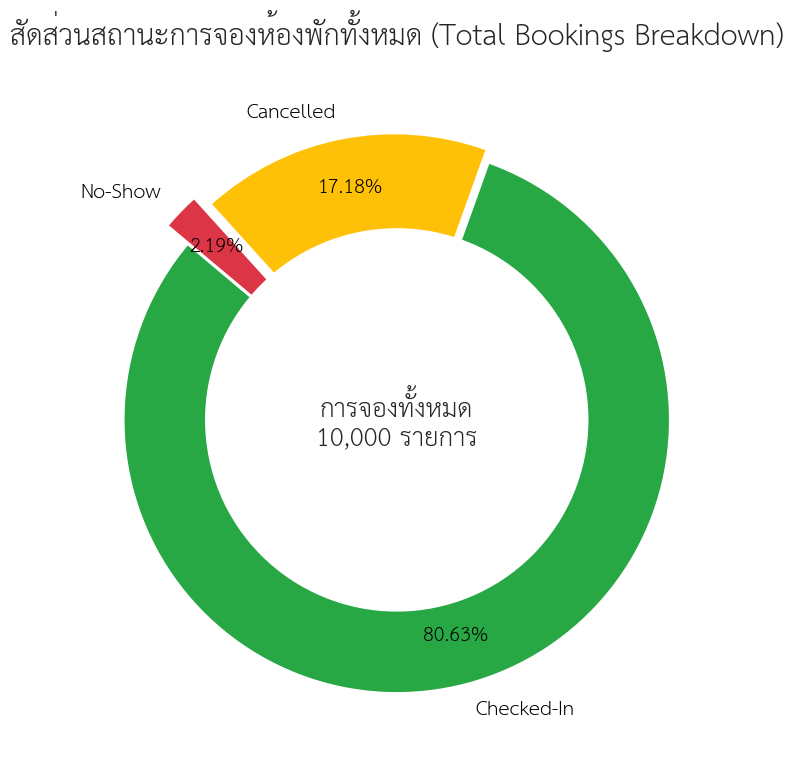

In [6]:
# ==============================================================================
# สรุปภาพรวมสถานะการจอง (Booking Status Overview)
# ==============================================================================

# 1. เตรียมข้อมูล
status_counts = df['status'].value_counts()

# 2. วาดกราฟ Donut Chart
plt.figure(figsize=(8, 8))

# ใช้สีจาก Global Config (น้ำเงิน=เข้าพักปกติ, ชมพู=ยกเลิก, แดง=No-show)
# (เรียงลำดับตาม value_counts ซึ่งปกติจะเป็น Checked-In, Cancelled, No-Show)
my_palette = [C_BLUE, C_PINK, C_RED]

# ใช้ **PIE_PROPS เพื่อโยนการตั้งค่าทั้งหมดเข้าไปในบรรทัดเดียว
plt.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=my_palette,
    explode=(0, 0.05, 0.1),
    **PIE_PROPS  # เรียกใช้ค่าที่ตั้งไว้ล่วงหน้าจาก Global Config
)

# สร้างวงกลมสีขาวตรงกลาง (ใส่ตัวเลข 0.70 เป็นรัศมีได้เลย จะได้ไม่ต้องสร้างตัวแปรเพิ่ม)
plt.gca().add_artist(plt.Circle((0,0), 0.70, fc='white'))

# 3. ตกแต่งหัวข้อและข้อความตรงกลาง
plt.title('สัดส่วนสถานะการจองห้องพักทั้งหมด (Total Bookings Breakdown)', weight='bold', pad=25)

plt.text(0, 0, f'การจองทั้งหมด\n{len(df):,} รายการ',
         ha='center', va='center', fontsize=18, weight='bold')

plt.tight_layout()
plt.show()

### H1: ถึงจะมีจำนวนการ Cancel เยอะกว่ามาก แต่ No-Show สร้างความเสียหายสุทธิมากกว่า

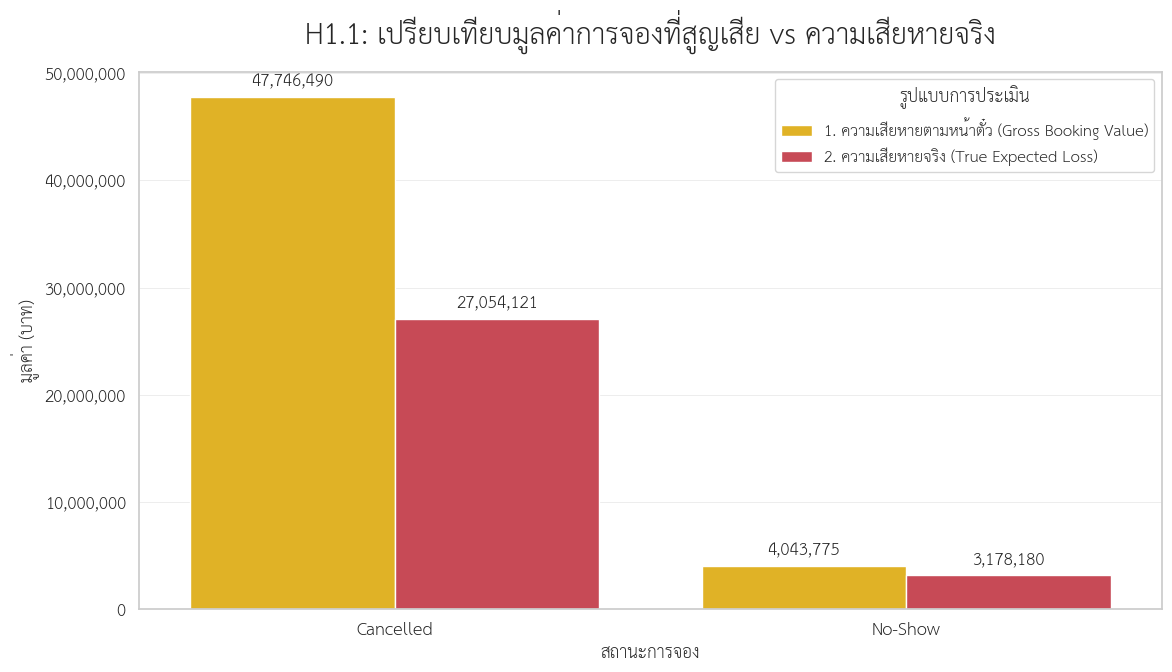

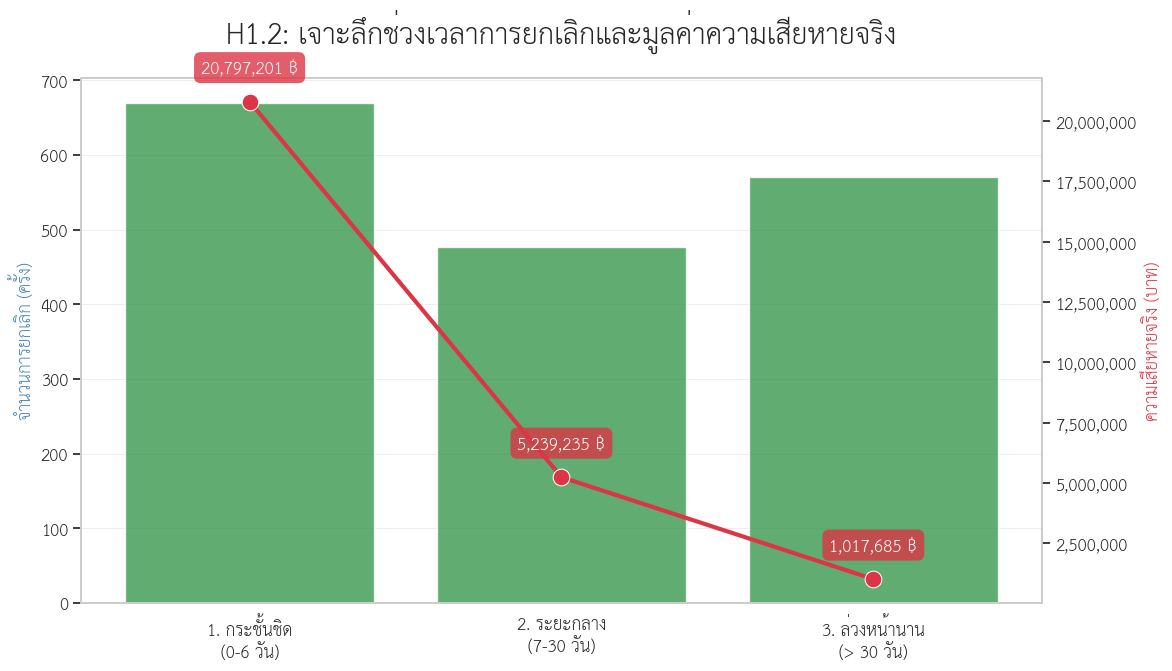

In [25]:
# ==============================================================================
# 1. เตรียมข้อมูลทำกราฟ H1.1 (FIXED: ดึง gross_revenue มาพล็อตยอดรวม)
# ==============================================================================
h1_advanced = df[df['status'].isin(['Cancelled', 'No-Show'])].groupby('status', observed=False).agg(
    gross_loss=('gross_revenue', 'sum'),
    true_loss=('true_expected_loss', 'sum')
).reset_index()

h1_melted = h1_advanced.melt(id_vars='status', var_name='Loss Type', value_name='Amount')
h1_melted['Loss Type Name'] = h1_melted['Loss Type'].map({
    'gross_loss': '1. ความเสียหายตามหน้าตั๋ว (Gross Booking Value)',
    'true_loss': '2. ความเสียหายจริง (True Expected Loss)'
})

# 2. วาดกราฟ H1.1
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=h1_melted, x='status', y='Amount', hue='Loss Type Name',
                 palette=[C_PINK, C_RED])

# จัดการ Grid
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='-', alpha=0.2, linewidth=0.5)

plt.title('H1.1: เปรียบเทียบมูลค่าการจองที่สูญเสีย vs ความเสียหายจริง', weight='bold', pad=20)
plt.ylabel('มูลค่า (บาท)')
plt.xlabel('สถานะการจอง')
plt.legend(title='รูปแบบการประเมิน', frameon=True)

# ใส่ตัวเลขกำกับ
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():,.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=12, weight='bold', xytext=(0, 5),
                   textcoords='offset points')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# H1.2: เจาะลึกช่วงเวลาการยกเลิก (Clean Grid & Global Colors)
# ------------------------------------------------------------------------------

# 1. เตรียมข้อมูล
cancels = df[df['status'] == 'Cancelled'].copy()

bins_h1 = [-1, 6, 30, 9999]
# เรียงลำดับตามสากลนิยม (เวลาน้อย -> เวลามาก) เพื่อให้อ่านง่ายที่สุด
labels_h1 = ['1. กระชั้นชิด\n(0-6 วัน)', '2. ระยะกลาง\n(7-30 วัน)', '3. ล่วงหน้านาน\n(> 30 วัน)']
cancels['cancel_window'] = pd.cut(cancels['recovery_days'], bins=bins_h1, labels=labels_h1)

window_stats = cancels.groupby('cancel_window', observed=False).agg(
    booking_count=('booking_id', 'count'),
    true_loss=('true_expected_loss', 'sum')
).reset_index()

# 2. วาดกราฟ H1.2
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

# กราฟแท่ง (ใช้ C_BLUE) ไม่ต้องใส่ hue เพื่อลด warning
sns.barplot(data=window_stats, x='cancel_window', y='booking_count',
            color=C_BLUE, ax=ax1, alpha=0.8)

# กราฟเส้น (ใช้ C_RED)
sns.lineplot(data=window_stats, x='cancel_window', y='true_loss', color=C_RED,
             marker='o', markersize=12, linewidth=3, ax=ax2)

# --- จัดการ Grid ของ ax1 (แกนหลัก) ---
ax1.set_axisbelow(True)
ax1.grid(axis='y', color='gray', linestyle='-', alpha=0.2, linewidth=0.5)
ax2.grid(False) # ปิด Grid ของแกนที่สอง

ax1.set_ylabel('จำนวนการยกเลิก (ครั้ง)', color='#4682B4', weight='bold')
ax2.set_ylabel('ความเสียหายจริง (บาท)', color=C_RED, weight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# --- แก้บั๊ก Label พิกัดเพี้ยน ---
# ดึงตำแหน่ง x และ y จากจุดบนกราฟเส้นมาโดยตรง
x_coords = ax2.lines[0].get_xdata()
y_coords = ax2.lines[0].get_ydata()

for x, y in zip(x_coords, y_coords):
    ax2.text(x, y + (max(y_coords) * 0.05), # ดันข้อความขึ้นไปเหนือจุด 5%
             f"{y:,.0f} ฿",
             color='white', ha='center', va='bottom', weight='bold', fontsize=12,
             bbox=dict(facecolor=C_RED, alpha=0.8, edgecolor='none', boxstyle='round,pad=0.4'))

plt.title('H1.2: เจาะลึกช่วงเวลาการยกเลิกและมูลค่าความเสียหายจริง', weight='bold', pad=25)
ax1.set_xlabel('')
plt.tight_layout()
plt.show()

In [27]:
# ==============================================================================
# เช็คจำนวนคน และ Gross Revenue แบ่งตามช่วงระยะเวลายกเลิก (Safe Version)
# ==============================================================================

# 1. กรองเฉพาะกลุ่มที่ยกเลิก (Cancelled)
cancels = df[df['status'] == 'Cancelled'].copy()

# 2. กำหนดเกณฑ์ช่วงเวลาที่เราต้องการ
bins = [-1, 6, 30, 9999]
labels = ['1. กระชั้นชิด (0-6 วัน)', '2. ระยะกลาง (7-30 วัน)', '3. ล่วงหน้านาน (> 30 วัน)']

# 3. จัดกลุ่มข้อมูล
cancels['cancel_window'] = pd.cut(cancels['recovery_days'], bins=bins, labels=labels)

# 4. ใช้ groupby คำนวณ (ใช้ชื่อตัวแปรภาษาอังกฤษเพื่อป้องกัน Error)
cancel_summary = cancels.groupby('cancel_window', observed=False).agg(
    booking_count=('booking_id', 'count'),
    total_gross=('gross_revenue', 'sum')
).reset_index()

# เรียงลำดับจากกระชั้นชิด ไปหาล่วงหน้านาน
cancel_summary = cancel_summary.sort_values('cancel_window')

# 5. จัด Format ตัวเลขให้สวยงาม
cancel_summary['booking_count'] = cancel_summary['booking_count'].apply(lambda x: f"{x:,.0f}")
cancel_summary['total_gross'] = cancel_summary['total_gross'].apply(lambda x: f"{x:,.0f} ฿")

# 6. เปลี่ยนชื่อคอลัมน์เป็นภาษาไทยให้สวยงาม (ทำเป็นขั้นตอนสุดท้าย)
cancel_summary.rename(columns={
    'cancel_window': 'ช่วงเวลาที่กดยกเลิกล่วงหน้า',
    'booking_count': 'จำนวนบุ๊กกิ้ง (ราย)',
    'total_gross': 'รวม Gross Revenue (บาท)'
}, inplace=True)

# แสดงผล
display(cancel_summary)

,ช่วงเวลาที่กดยกเลิกล่วงหน้า,จำนวนบุ๊กกิ้ง (ราย),รวม Gross Revenue (บาท)
0,1. กระชั้นชิด (0-6 วัน),670,"23,370,390 ฿"
1,2. ระยะกลาง (7-30 วัน),477,"11,177,000 ฿"
2,3. ล่วงหน้านาน (> 30 วัน),571,"13,199,100 ฿"


In [36]:
# ==============================================================================
# เช็คสัดส่วนการยกเลิก และ True Loss แบ่งตามช่วงเวลา (อัปเดตล่าสุด)
# ==============================================================================

# 1. กรองเฉพาะกลุ่มที่ยกเลิก
cancels = df[df['status'] == 'Cancelled'].copy()

# 2. แบ่งกลุ่มช่วงเวลา (0-6, 7-30, >30)
bins = [-1, 6, 30, 9999]
labels = ['1. กระชั้นชิด (0-6 วัน)', '2. ระยะกลาง (7-30 วัน)', '3. ล่วงหน้านาน (> 30 วัน)']
cancels['cancel_window'] = pd.cut(cancels['recovery_days'], bins=bins, labels=labels)

# 3. คำนวณจำนวนครั้ง และ True Loss
cancel_stats = cancels.groupby('cancel_window', observed=False).agg(
    booking_count=('booking_id', 'count'),
    true_loss=('true_expected_loss', 'sum')
).reset_index()

# 4. คำนวณสัดส่วนเปอร์เซ็นต์
total_cancels = cancel_stats['booking_count'].sum()
total_true_loss = cancel_stats['true_loss'].sum()

cancel_stats['booking_pct'] = (cancel_stats['booking_count'] / total_cancels) * 100
cancel_stats['loss_pct'] = (cancel_stats['true_loss'] / total_true_loss) * 100

# 5. จัด Format ตารางให้สวยงามพร้อมก๊อปปี้ไปใช้งาน
cancel_display = cancel_stats.copy()
cancel_display['booking_count'] = cancel_display['booking_count'].apply(lambda x: f"{x:,.0f} ครั้ง")
cancel_display['booking_pct'] = cancel_display['booking_pct'].apply(lambda x: f"{x:.1f}%")
cancel_display['true_loss'] = cancel_display['true_loss'].apply(lambda x: f"{x:,.0f} ฿")
cancel_display['loss_pct'] = cancel_display['loss_pct'].apply(lambda x: f"{x:.1f}%")

# เปลี่ยนชื่อคอลัมน์เป็นภาษาไทย
cancel_display.columns = [
    'กลุ่มช่วงเวลายกเลิก',
    'จำนวนการยกเลิก',
    'สัดส่วนการยกเลิก',
    'สร้างความเสียหายจริง (True Loss)',
    'สัดส่วนความเสียหาย'
]

print(f"=== สรุปภาพรวมการยกเลิกทั้งหมด: {total_cancels:,.0f} ครั้ง ===")
print(f"=== มูลค่าความเสียหายจริงรวม: {total_true_loss:,.0f} ฿ ===")
display(cancel_display)

=== สรุปภาพรวมการยกเลิกทั้งหมด: 1,718 ครั้ง ===
=== มูลค่าความเสียหายจริงรวม: 27,054,121 ฿ ===


,กลุ่มช่วงเวลายกเลิก,จำนวนการยกเลิก,สัดส่วนการยกเลิก,สร้างความเสียหายจริง (True Loss),สัดส่วนความเสียหาย
0,1. กระชั้นชิด (0-6 วัน),670 ครั้ง,"20,797,201 ฿",39.0%,76.9%
1,2. ระยะกลาง (7-30 วัน),477 ครั้ง,"5,239,235 ฿",27.8%,19.4%
2,3. ล่วงหน้านาน (> 30 วัน),571 ครั้ง,"1,017,685 ฿",33.2%,3.8%


### H2: การจองผ่านช่องทาง OTA อื่นๆทำให้มีการ Cancel และ No-Show มากกว่าจองตรงกับโรงแรม

=== สรุปยอดการยกเลิกทั้งหมด: 1,718 ครั้ง ===


,ช่องทางการจอง,จำนวนการยกเลิก,สัดส่วน (%)
0,OTA,"1,117 ครั้ง",65.0%
1,Direct,387 ครั้ง,22.5%
2,Wholesale,214 ครั้ง,12.5%


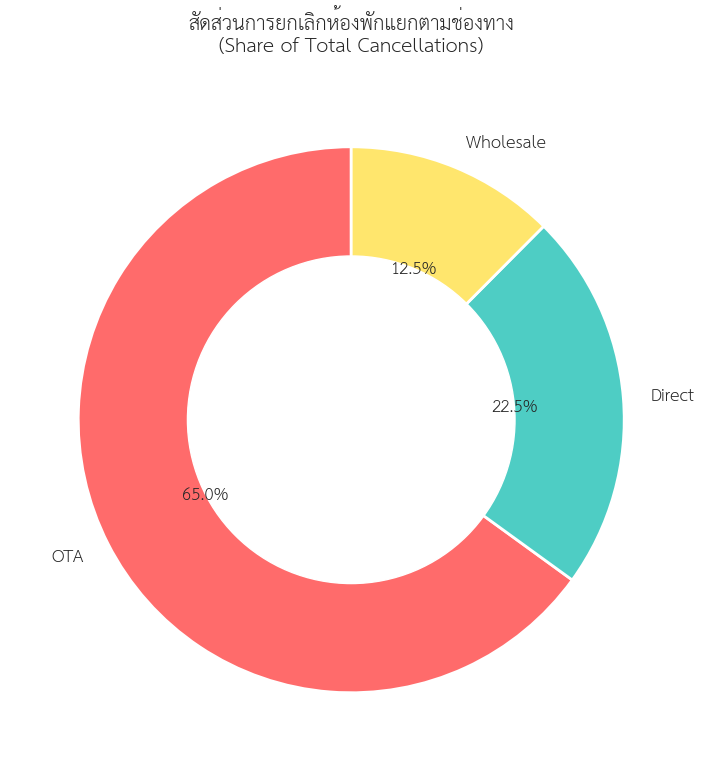

In [39]:
# ==============================================================================
# H2.1 (เพิ่มเติม): วิเคราะห์สัดส่วนการยกเลิกจากผลรวมทั้งหมด (Share of Total Cancellations)
# ==============================================================================

# 1. กรองเอาเฉพาะข้อมูล "คนที่ยกเลิก (Cancelled)" เท่านั้น
cancels_only = df[df['status'] == 'Cancelled'].copy()

# 2. นับจำนวนว่าแต่ละช่องทางมีการยกเลิกกี่ครั้ง
cancel_share = cancels_only['channel_type'].value_counts().reset_index()
cancel_share.columns = ['ช่องทางการจอง', 'จำนวนการยกเลิก']

# 3. คำนวณเป็นเปอร์เซ็นต์ "จากยอดการยกเลิกทั้งหมด"
total_cancels = cancel_share['จำนวนการยกเลิก'].sum()
cancel_share['สัดส่วน (%)'] = (cancel_share['จำนวนการยกเลิก'] / total_cancels) * 100

# --- ส่วนที่ 1: พิมพ์ตารางสรุปผล ---
print(f"=== สรุปยอดการยกเลิกทั้งหมด: {total_cancels:,.0f} ครั้ง ===")
display_df = cancel_share.copy()
display_df['จำนวนการยกเลิก'] = display_df['จำนวนการยกเลิก'].apply(lambda x: f"{x:,.0f} ครั้ง")
display_df['สัดส่วน (%)'] = display_df['สัดส่วน (%)'].apply(lambda x: f"{x:.1f}%")
display(display_df)

# --- ส่วนที่ 2: วาดกราฟโดนัท (Donut Chart) ---
plt.figure(figsize=(8, 8))

# ตั้งค่าสี (สามารถปรับเปลี่ยนได้ตามต้องการ)
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']

# วาดกราฟ Pie แบบเจาะรูตรงกลาง (Donut)
plt.pie(cancel_share['จำนวนการยกเลิก'],
        labels=cancel_share['ช่องทางการจอง'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 12, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# วาดวงกลมสีขาวทับตรงกลางให้เป็นโดนัท
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('สัดส่วนการยกเลิกห้องพักแยกตามช่องทาง\n(Share of Total Cancellations)', weight='bold', pad=20, fontsize=14)
plt.tight_layout()
plt.show()

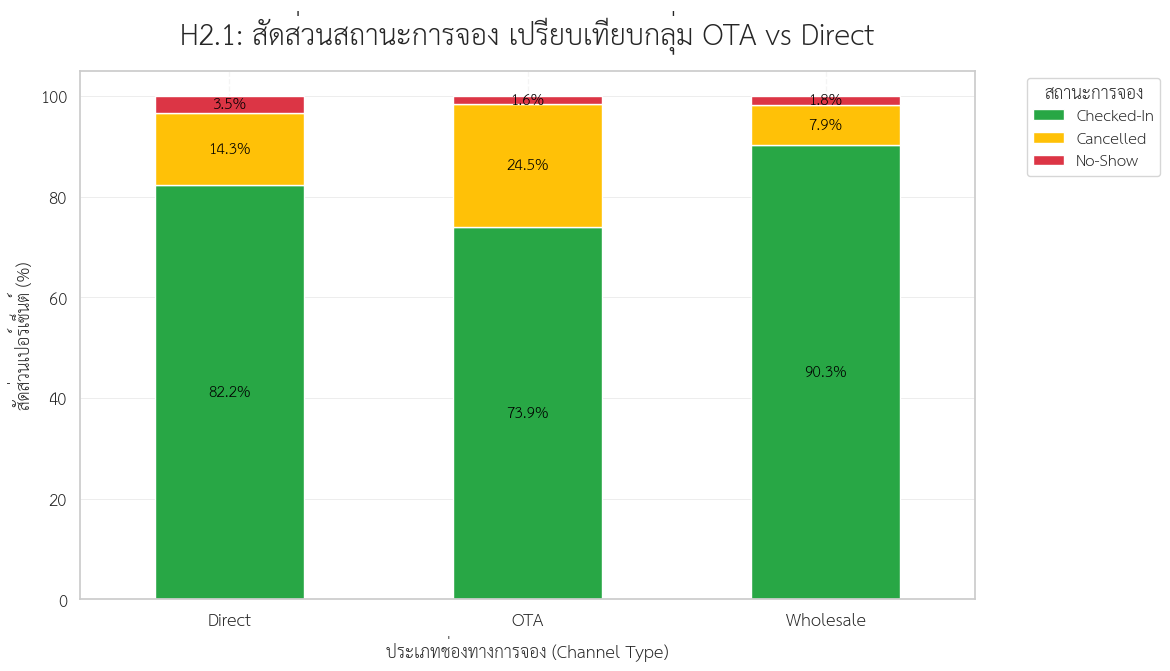

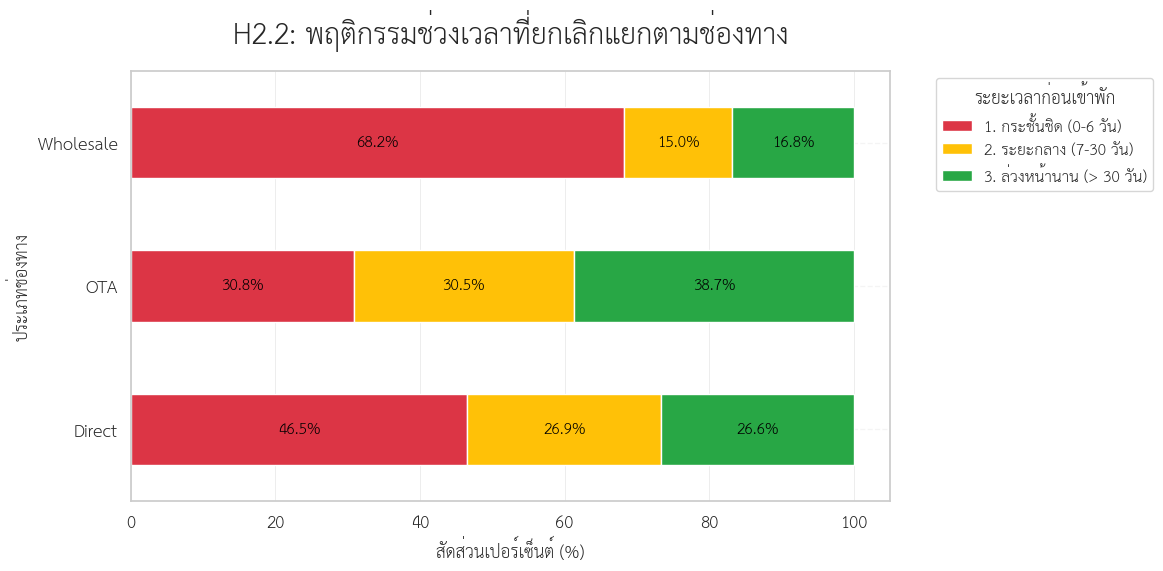

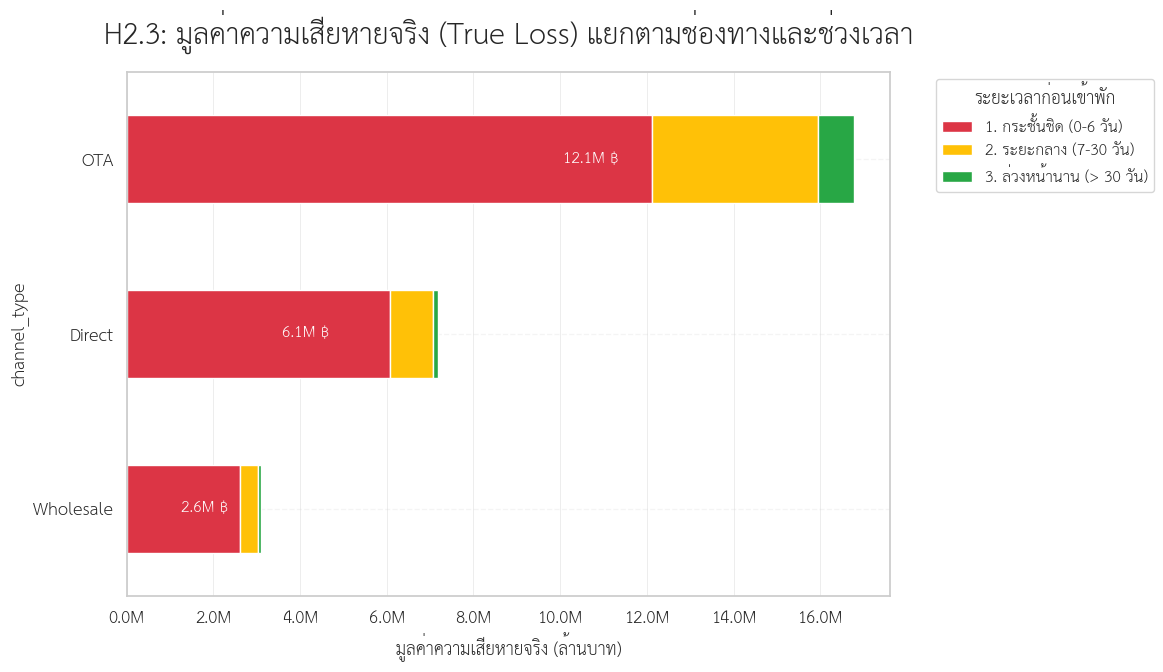


สรุปค่าเฉลี่ย Lead Time (การจองล่วงหน้า) ของกลุ่มที่ยกเลิก
Direct......... 63.1 วัน
OTA............ 71.4 วัน
Wholesale...... 35.7 วัน


In [42]:
# ==============================================================================
# H2: การวิเคราะห์ความน่าเชื่อถือแยกตามประเภทช่องทาง (OTA vs Direct)
# ==============================================================================

# --- H2.1: สัดส่วนสถานะการจอง (Stacked Bar) ---
# 1. จัดกลุ่มและคำนวณ % ตามประเภทช่องทาง
h2_data = pd.crosstab(df['channel_type'], df['status'], normalize='index') * 100
h2_data = h2_data[['Checked-In', 'Cancelled', 'No-Show']] # เรียงลำดับให้ตรงกับสี

# 2. วาดกราฟ (ใช้สีหลัก: ฟ้า=เข้าพัก, ชมพู=ยกเลิก, แดง=No-Show)
plt.figure(figsize=(12, 7))
ax = h2_data.plot(kind='bar', stacked=True, color=[C_BLUE, C_PINK, C_RED], ax=plt.gca())

# จัดการ Grid ให้สะอาดและอยู่ข้างหลัง
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='-', alpha=0.2, linewidth=0.5)

plt.title("H2.1: สัดส่วนสถานะการจอง เปรียบเทียบกลุ่ม OTA vs Direct", weight='bold', pad=20)
plt.ylabel("สัดส่วนเปอร์เซ็นต์ (%)")
plt.xlabel("ประเภทช่องทางการจอง (Channel Type)")
plt.xticks(rotation=0)
plt.legend(title='สถานะการจอง', bbox_to_anchor=(1.05, 1), loc='upper left')

# ใส่ตัวเลข % บนท่อนกราฟ
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='black', weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# --- H2.2: เจาะลึกช่วงเวลาการยกเลิก (100% Stacked Barh) ---

# 1. กรองเฉพาะกลุ่มที่ยกเลิก
cancels = df[df['status'] == 'Cancelled'].copy()

# 2. จัดกลุ่มระยะเวลา (ใช้ pd.cut แบบ Vectorized แทน apply เพื่อความรวดเร็ว)
bins_window = [-1, 6, 30, 9999]
labels_window = ['1. กระชั้นชิด (0-6 วัน)', '2. ระยะกลาง (7-30 วัน)', '3. ล่วงหน้านาน (> 30 วัน)']
cancels['cancel_window'] = pd.cut(cancels['recovery_days'], bins=bins_window, labels=labels_window)

# 3. คำนวณสัดส่วน % แนวนอน
channel_window = pd.crosstab(cancels['channel_type'], cancels['cancel_window'], normalize='index') * 100

# 4. วาดกราฟ
plt.figure(figsize=(12, 6))
# ชุดสีพิเศษ (แดง=กระชั้นชิด/วิกฤต, ชมพู=ระยะกลาง, ฟ้า=ล่วงหน้านาน/ปลอดภัย)
window_palette = [C_RED, C_PINK, C_BLUE]
ax = channel_window.plot(kind='barh', stacked=True, color=window_palette, ax=plt.gca())

# กราฟแนวนอนต้องเปิด Grid แกน X
ax.set_axisbelow(True)
ax.grid(axis='x', color='gray', linestyle='-', alpha=0.2, linewidth=0.5)

plt.title('H2.2: พฤติกรรมช่วงเวลาที่ยกเลิกแยกตามช่องทาง', weight='bold', pad=20)
plt.xlabel('สัดส่วนเปอร์เซ็นต์ (%)')
plt.ylabel('ประเภทช่องทาง')
plt.legend(title='ระยะเวลาก่อนเข้าพัก', bbox_to_anchor=(1.05, 1), loc='upper left')

# ใส่ตัวเลข %
for c in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='black', weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# --- H2.3: วิเคราะห์ความเสียหายจริง (True Loss) รายช่องทาง ---

# 1. จัดกลุ่มรวมมูลค่าความเสียหายจริง
loss_by_channel = cancels.groupby(['channel_type', 'cancel_window'], observed=False)['true_expected_loss'].sum().unstack()

# เรียงลำดับจากเสียหายมากไปน้อย
loss_by_channel['Total'] = loss_by_channel.sum(axis=1)
loss_by_channel = loss_by_channel.sort_values('Total', ascending=True).drop(columns=['Total'])

# 2. วาดกราฟ
plt.figure(figsize=(12, 7))
ax = loss_by_channel.plot(kind='barh', stacked=True, color=window_palette, ax=plt.gca())

ax.set_axisbelow(True)
ax.grid(axis='x', color='gray', linestyle='-', alpha=0.2, linewidth=0.5)

plt.title('H2.3: มูลค่าความเสียหายจริง (True Loss) แยกตามช่องทางและช่วงเวลา', weight='bold', pad=20)
plt.xlabel('มูลค่าความเสียหายจริง (ล้านบาท)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.legend(title='ระยะเวลาก่อนเข้าพัก', bbox_to_anchor=(1.05, 1), loc='upper left')

# เน้นตัวเลขความเสียหายในท่อน "กระชั้นชิด" (สีแดง)
for i, (idx, row) in enumerate(loss_by_channel.iterrows()):
    short_loss = row.get('1. กระชั้นชิด (0-6 วัน)', 0) # ปรับชื่อให้ตรงกับ label_window
    if short_loss > 0:
        x_pos = row.sum() - (short_loss / 2) # หาตำแหน่งกึ่งกลางของกล่องสีแดง
        ax.text(x_pos, i, f'{short_loss/1e6:.1f}M ฿',
                ha='center', va='center', color='white', weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# สถิติเสริมประกอบสไลด์
print("\n" + "="*50)
print("สรุปค่าเฉลี่ย Lead Time (การจองล่วงหน้า) ของกลุ่มที่ยกเลิก")
print("="*50)
lt_stats = cancels.groupby('channel_type')['lead_time'].mean()
for channel, val in lt_stats.items():
    print(f"{channel:.<15} {val:.1f} วัน")

### H3: การยกเลิกส่วนใหญ่เกิดจากการจองที่มี Policy แบบ Flexible การบังคับวางมัดจำ (Strict Deposit Policy) สามารถกดอัตราการยกเลิกให้ต่ำลงได้

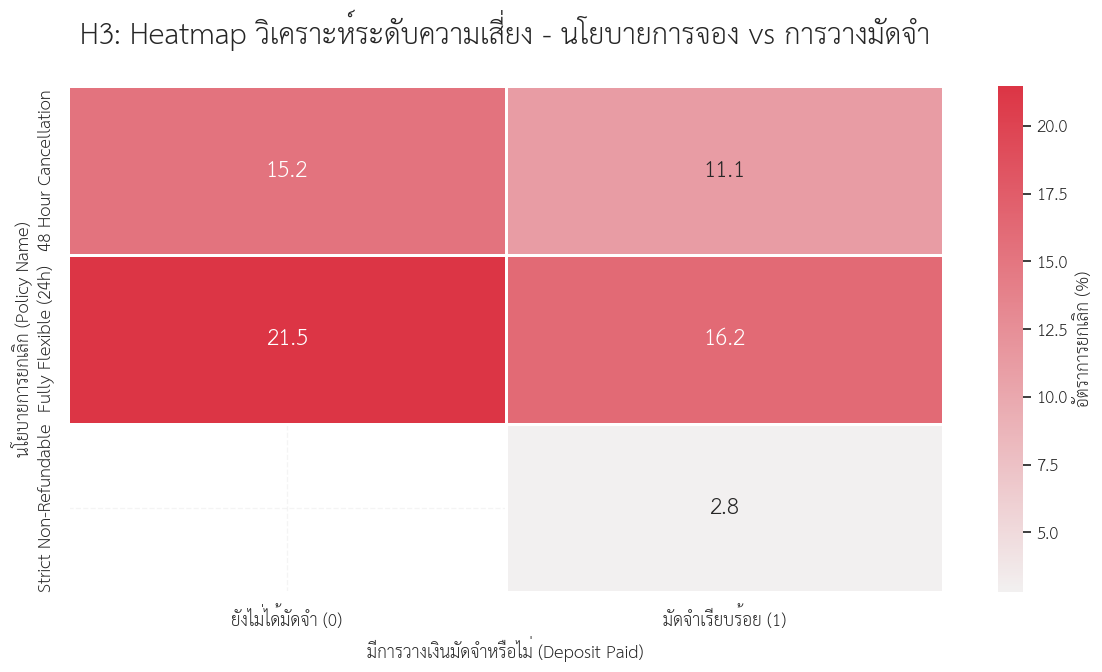


════════════════════════════════════════════════════════════
║ POLICY NAME               │ DEPOSIT    │  CANCEL RATE ║
╟───────────────────────────┼────────────┼───────────────╢
║ Fully Flexible (24h)      │ Unpaid     │       21.48% ║
║ Fully Flexible (24h)      │ Paid       │       16.20% ║
║ 48 Hour Cancellation      │ Unpaid     │       15.24% ║
║ 48 Hour Cancellation      │ Paid       │       11.11% ║
║ Strict Non-Refundable     │ Paid       │        2.78% ║
════════════════════════════════════════════════════════════


In [29]:
# ==============================================================================
# H3: การวิเคราะห์จุดวิกฤต (Sequential Red Heatmap Version)
# ==============================================================================

# 1. เตรียมข้อมูลด้วย Pivot Table
h3_pivot = df.pivot_table(
    index='policy_name',
    columns='deposit_paid',
    values='status',
    aggfunc=lambda x: (x == 'Cancelled').mean() * 100
)

# 2. วาด Heatmap
plt.figure(figsize=(12, 7))

# --- สร้าง Custom Colormap: ไล่จาก ขาว (เสี่ยงต่ำ) -> แดงเข้ม C_RED (เสี่ยงสูง) ---
cmap = sns.light_palette(C_RED, as_cmap=True)

ax = sns.heatmap(
    h3_pivot,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'อัตราการยกเลิก (%)'}
)

# 3. ตกแต่งหัวข้อและป้ายกำกับ
plt.title('H3: Heatmap วิเคราะห์ระดับความเสี่ยง - นโยบายการจอง vs การวางมัดจำ', weight='bold', pad=30)
plt.ylabel('นโยบายการยกเลิก (Policy Name)', weight='bold')
plt.xlabel('มีการวางเงินมัดจำหรือไม่ (Deposit Paid)', weight='bold')

# ปรับชื่อแกน X ให้ชัดเจน (สมมติว่า deposit_paid ในข้อมูลคุณเป็น 0 กับ 1)
ax.set_xticklabels(['ยังไม่ได้มัดจำ (0)', 'มัดจำเรียบร้อย (1)'])

plt.tight_layout()
plt.show()

# 4. สรุปตารางตัวเลขเรียงตามระดับความรุนแรง
print("\n" + "═"*60)
print(f"║ {'POLICY NAME':<25} │ {'DEPOSIT':<10} │ {'CANCEL RATE':>12} ║")
print("╟" + "─"*27 + "┼" + "─"*12 + "┼" + "─"*15 + "╢")

# เรียงลำดับจาก Cancel Rate สูงไปต่ำ (วิกฤตที่สุดอยู่บน)
# เปลี่ยนวิธี reset_index เพื่อให้วนลูปง่ายขึ้น
summary = df.groupby(['policy_name', 'deposit_paid'], observed=False)['status']\
            .apply(lambda x: (x == 'Cancelled').mean()*100).reset_index(name='cancel_rate')
summary = summary.sort_values('cancel_rate', ascending=False)

for _, row in summary.iterrows():
    policy = row['policy_name']
    deposit = row['deposit_paid']
    val = row['cancel_rate']

    # เช็คเงื่อนไข deposit_paid ว่าเป็นเลข 1, 0 หรือ boolean
    status_text = "Paid" if deposit == 1 or deposit == True else "Unpaid"

    # ไฮไลท์สีแดงถ้าอัตราการยกเลิกสูงกว่า 20%
    color_start = "\033[91m" if val > 20 else ""
    reset_color = "\033[0m"

    print(f"║ {color_start}{policy:<25}{reset_color} │ {status_text:<10} │ {val:>11.2f}% ║")

print("═"*60)

In [12]:
# ==============================================================================
# วิเคราะห์หา Sweet Spot & จัดอันดับความเสี่ยง (Deposit Necessity Index)
# ==============================================================================

# 0. สร้างกลุ่ม 3 ระดับ (Tier) เฉพาะสำหรับการจัดอันดับนโยบายมัดจำให้เข้าใจง่าย
def categorize_lead_time_3tiers(days):
    if days > 30: return '3. ล่วงหน้านาน (> 30 วัน)'
    elif days >= 7: return '2. ระยะกลาง (7-30 วัน)'
    else: return '1. กระชั้นชิด (0-6 วัน)'

df['lead_time_tier'] = df['lead_time'].apply(categorize_lead_time_3tiers)

# 1. หา Cancel Rate (เปลี่ยนมาใช้ lead_time_tier)
segment_analysis = df.groupby(['channel_type', 'lead_time_tier'], observed=False).agg(
    total_bookings=('booking_id', 'count'),
    cancel_rate=('status', lambda x: (x == 'Cancelled').mean() * 100)
).reset_index()

# 2. หาความเสียหายเฉลี่ยเมื่อยกเลิก (เปลี่ยนมาใช้ lead_time_tier)
loss_when_cancelled = df[df['status'] != 'Checked-In'].groupby(['channel_type', 'lead_time_tier'], observed=False)['true_expected_loss'].mean().reset_index(name='avg_loss_if_cancelled')

# 3. นำมาประกอบร่างกันและสร้าง Index
segment_analysis = segment_analysis.merge(loss_when_cancelled, on=['channel_type', 'lead_time_tier'])
segment_analysis['deposit_necessity'] = (segment_analysis['cancel_rate'] / 100) * segment_analysis['avg_loss_if_cancelled']

# 4. จัดอันดับและแสดงผล
sweet_spot = segment_analysis.sort_values('deposit_necessity', ascending=False)

print("=== จัดอันดับกลุ่มเป้าหมายที่ควรบังคับเก็บมัดจำ (Risk-to-Revenue Mapping) ===")
print("ดัชนี (Index) ยิ่งสูง = ยิ่งมีความเสี่ยงสูง และคุ้มค่าที่จะตั้งกำแพงเก็บมัดจำมากที่สุด\n")
print(sweet_spot[['channel_type', 'lead_time_tier', 'cancel_rate', 'avg_loss_if_cancelled', 'deposit_necessity']].round(2).to_string(index=False))

=== จัดอันดับกลุ่มเป้าหมายที่ควรบังคับเก็บมัดจำ (Risk-to-Revenue Mapping) ===
ดัชนี (Index) ยิ่งสูง = ยิ่งมีความเสี่ยงสูง และคุ้มค่าที่จะตั้งกำแพงเก็บมัดจำมากที่สุด

channel_type            lead_time_tier  cancel_rate  avg_loss_if_cancelled  deposit_necessity
         OTA   1. กระชั้นชิด (0-6 วัน)        19.23              28,241.30           5,431.02
   Wholesale    2. ระยะกลาง (7-30 วัน)        16.39              23,932.92           3,923.43
         OTA 3. ล่วงหน้านาน (> 30 วัน)        27.33              13,707.74           3,746.81
         OTA    2. ระยะกลาง (7-30 วัน)        16.85              21,608.76           3,641.31
      Direct    2. ระยะกลาง (7-30 วัน)        16.60              20,212.07           3,355.67
   Wholesale 3. ล่วงหน้านาน (> 30 วัน)        17.65              18,155.37           3,203.89
      Direct 3. ล่วงหน้านาน (> 30 วัน)        16.99              18,627.36           3,164.41
      Direct   1. กระชั้นชิด (0-6 วัน)         3.58               9,467.60        

### H4: อัตราการยกเลิกจะพุ่งสูงขึ้นอย่างผิดปกติในช่วงช่วงเทศกาล หรือตามฤดูกาลต่างๆ

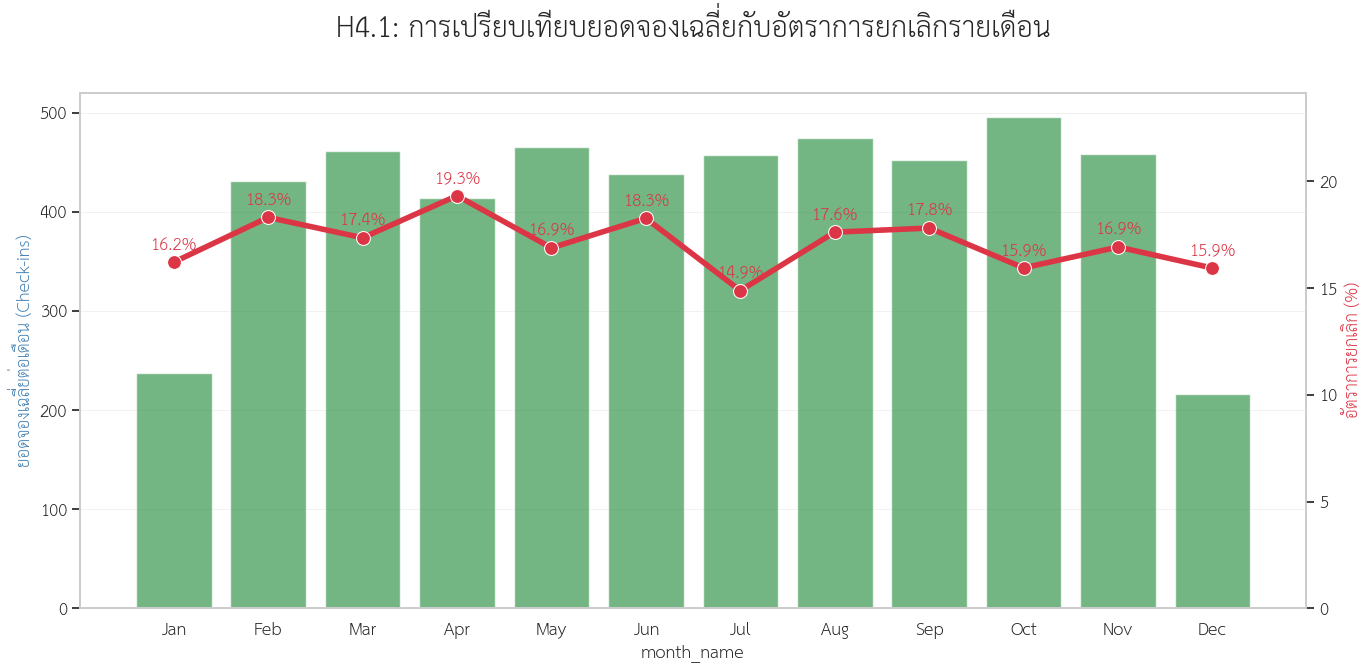

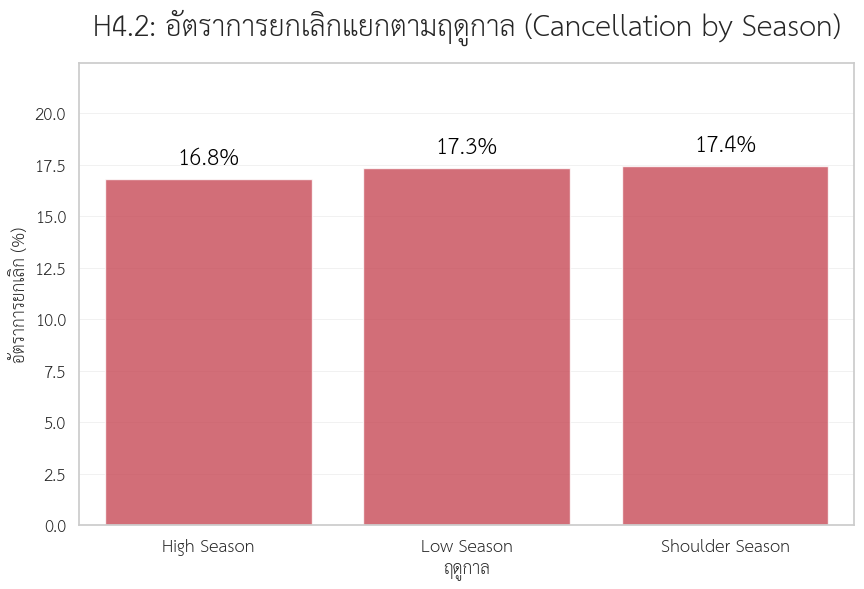

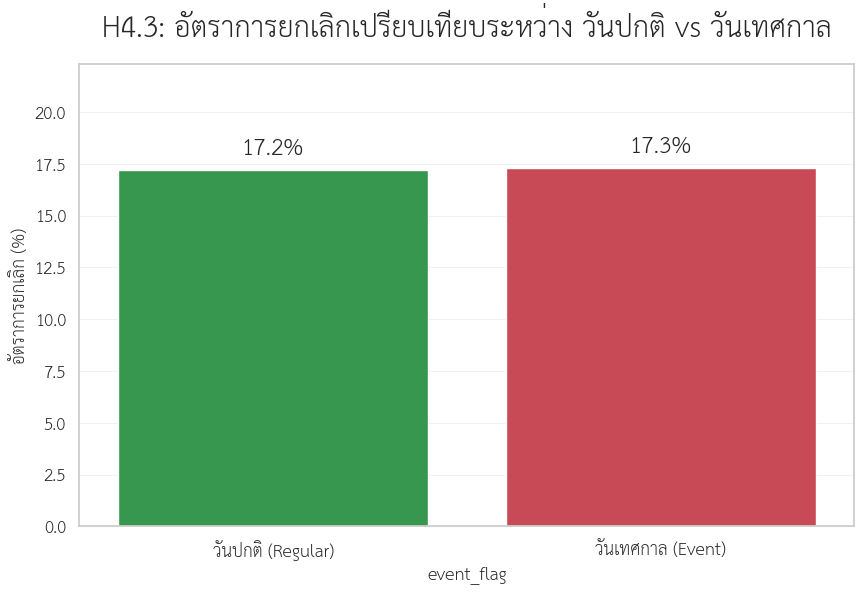

In [30]:
# ==============================================================================
# H4: ผลการวิเคราะห์สมมติฐานด้านเทศกาลและฤดูกาล (Fixed & Clean Version)
# ==============================================================================

# --- 1. เตรียมมิติของเวลาเพิ่มเติม (ใช้ df หลักที่คลีนแล้วได้เลย) ---
df['month_name'] = df['check_in_date'].dt.strftime('%b')
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['month_name'] = pd.Categorical(df['month_name'], categories=months_order, ordered=True)

# ==============================================================================
# H4.1: แนวโน้มความต้องการและอัตราการยกเลิกรายเดือน (ฉบับปรับปรุงพื้นที่ด้านบน)
# ==============================================================================
plt.figure(figsize=(14, 7))

# 1. คำนวณข้อมูล (Logic เดิม)
monthly_stats = df.groupby('month_name', observed=False).agg(
    total_bookings=('booking_id', 'count'),
    unique_years=('year_month', 'nunique'),
    cancel_rate=('status', lambda x: (x == 'Cancelled').mean() * 100)
).reset_index()

monthly_stats['avg_bookings'] = monthly_stats['total_bookings'] / monthly_stats['unique_years']

# 2. วาดกราฟแท่ง (Demand) - ใช้สีฟ้า C_BLUE
ax1 = sns.barplot(data=monthly_stats, x='month_name', y='avg_bookings',
                  color=C_BLUE, alpha=0.7) # แก้จาก hue เป็น color ล้วนเพื่อลด warning

ax1.set_axisbelow(True)
ax1.grid(axis='y', color='gray', linestyle='-', alpha=0.15, linewidth=0.5)
plt.ylabel('ยอดจองเฉลี่ยต่อเดือน (Check-ins)', color='#4682B4', weight='bold')

# 3. วาดกราฟเส้น (Risk) - ใช้สีแดง C_RED
ax2 = ax1.twinx()
sns.lineplot(data=monthly_stats, x='month_name', y='cancel_rate',
             color=C_RED, marker='o', linewidth=4, markersize=10, ax=ax2)

ax2.set_ylabel('อัตราการยกเลิก (%)', color=C_RED, weight='bold')
ax2.grid(False)

# เพิ่มพื้นที่ด้านบน (Headroom) ให้แกนอัตราการยกเลิก
ax2.set_ylim(0, monthly_stats['cancel_rate'].max() * 1.25)

# 4. ใส่ตัวเลขกำกับ
for x, y in zip(range(len(monthly_stats)), monthly_stats['cancel_rate']):
    ax2.text(x, y + 0.4, f'{y:.1f}%', ha='center', va='bottom',
             color=C_RED, weight='bold', fontsize=12)

plt.title('H4.1: การเปรียบเทียบยอดจองเฉลี่ยกับอัตราการยกเลิกรายเดือน', weight='bold', pad=40)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# H4.2: อัตราการยกเลิกแบ่งตามฤดูกาล (Seasonality)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

season_stats = df.groupby('season', observed=False)['status'].value_counts(normalize=True).unstack().fillna(0)
season_stats['cancel_rate'] = season_stats.get('Cancelled', 0) * 100

ax = sns.barplot(x=season_stats.index, y=season_stats['cancel_rate'],
                 color=C_RED, alpha=0.8)

ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='-', alpha=0.15, linewidth=0.5)

plt.title('H4.2: อัตราการยกเลิกแยกตามฤดูกาล (Cancellation by Season)', weight='bold', pad=20)
plt.ylabel('อัตราการยกเลิก (%)')
plt.xlabel('ฤดูกาล')
plt.ylim(0, max(season_stats['cancel_rate']) + 5)

for i, v in enumerate(season_stats['cancel_rate']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', weight='bold', color='black')

plt.show()

# ------------------------------------------------------------------------------
# H4.3: อัตราการยกเลิก: วันปกติ vs วันเทศกาล (Events)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

event_stats = df.groupby('event_flag', observed=False)['status'].value_counts(normalize=True).unstack().fillna(0)
event_stats['cancel_rate'] = event_stats.get('Cancelled', 0) * 100

# เปรียบเทียบวันปกติ (C_BLUE) vs วันเทศกาล (C_RED) - อันนี้ถูกต้องตามหลักจิตวิทยาสีที่สุดครับ!
ax = sns.barplot(x=event_stats.index.astype(str), y=event_stats['cancel_rate'],
                 hue=event_stats.index.astype(str), palette=[C_BLUE, C_RED], legend=False)

ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='-', alpha=0.15, linewidth=0.5)

plt.title('H4.3: อัตราการยกเลิกเปรียบเทียบระหว่าง วันปกติ vs วันเทศกาล', weight='bold', pad=20)
plt.ylabel('อัตราการยกเลิก (%)')
plt.xticks([0, 1], ['วันปกติ (Regular)', 'วันเทศกาล (Event)'])
plt.ylim(0, max(event_stats['cancel_rate']) + 5)

for i, v in enumerate(event_stats['cancel_rate']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', weight='bold')

plt.show()

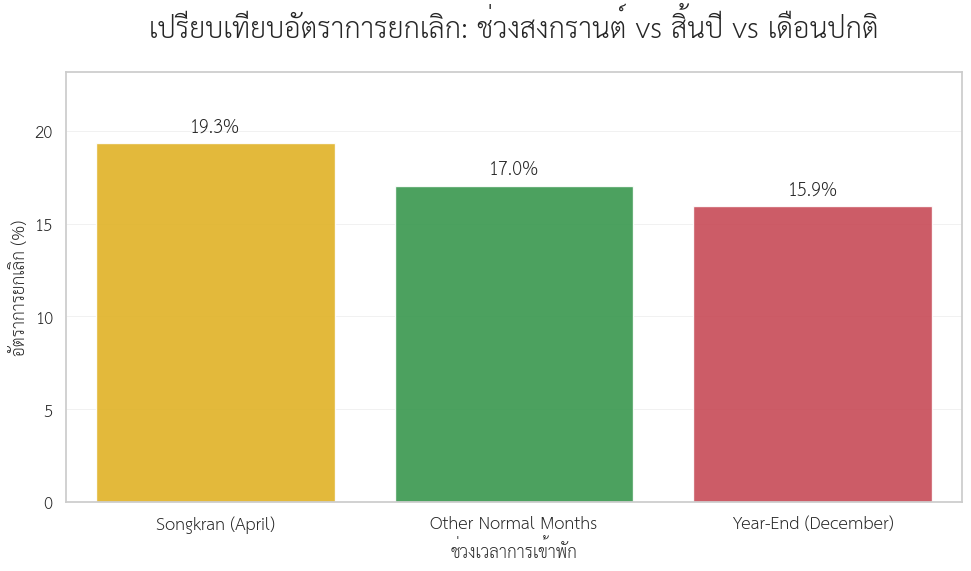


═════════════════════════════════════════════════════════════════
║ PERIOD TYPE               │      TOTAL │   CANCEL │     RATE % ║
╟───────────────────────────┼────────────┼──────────┼────────────╢
║ Songkran (April)          │        828 │      160 │      19.32% ║
║ Other Normal Months       │      8,739 │    1,489 │      17.04% ║
║ Year-End (December)       │        433 │       69 │      15.94% ║
═════════════════════════════════════════════════════════════════


In [14]:
# ==============================================================================
# H4.4: เจาะลึกเปรียบเทียบพฤติกรรม 2 เทศกาลหลัก (Songkran vs Year-End)
# ==============================================================================

# 1. เตรียมข้อมูลจัดกลุ่มเทศกาล (ใช้ df หลักที่คลีนแล้ว)
df_fest = df.copy()

conditions = [
    (df_fest['check_in_date'].dt.month == 4),  # เมษายน (สงกรานต์)
    (df_fest['check_in_date'].dt.month == 12) # ธันวาคม (สิ้นปี)
]
choices = ['Songkran (April)', 'Year-End (December)']

# คอลัมน์ใหม่สำหรับดูประเภทเทศกาล
df_fest['period_type'] = np.select(conditions, choices, default='Other Normal Months')

# 2. คำนวณสถิติการยกเลิก
fest_comparison = df_fest.groupby('period_type', observed=False).agg(
    total_bookings=('booking_id', 'count'),
    cancel_count=('status', lambda x: (x == 'Cancelled').sum()),
    cancel_rate_pct=('status', lambda x: (x == 'Cancelled').mean() * 100)
).reset_index()

# เรียงลำดับจาก Cancel Rate สูงไปต่ำ เพื่อให้สื่อสารได้ง่าย
fest_comparison = fest_comparison.sort_values('cancel_rate_pct', ascending=False)

# 3. วาดกราฟเปรียบเทียบ
plt.figure(figsize=(10, 6))

# กำหนดสีเฉพาะตัว: สงกรานต์ (ชมพู), สิ้นปี (แดง), ปกติ (ฟ้า)
# เราสร้าง palette list ให้ตรงกับลำดับใน fest_comparison
color_map = {
    'Songkran (April)': C_PINK,
    'Year-End (December)': C_RED,
    'Other Normal Months': C_BLUE
}
current_palette = [color_map[label] for label in fest_comparison['period_type']]

# วาดกราฟ
ax = sns.barplot(
    data=fest_comparison,
    x='period_type',
    y='cancel_rate_pct',
    hue='period_type',
    palette=current_palette,
    legend=False,
    alpha=0.9
)

# --- จัดการเส้น Grid: บาง จาง และอยู่ข้างหลังแท่งกราฟ ---
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='-', alpha=0.15, linewidth=0.5)

# ตกแต่งหัวข้อและป้ายกำกับ
plt.title('เปรียบเทียบอัตราการยกเลิก: ช่วงสงกรานต์ vs สิ้นปี vs เดือนปกติ', weight='bold', pad=25)
plt.ylabel('อัตราการยกเลิก (%)', weight='bold')
plt.xlabel('ช่วงเวลาการเข้าพัก', weight='bold')
plt.ylim(0, fest_comparison['cancel_rate_pct'].max() * 1.2) # เพิ่มพื้นที่ด้านบนกันเลขทับหัวข้อ

# ใส่ตัวเลข % กำกับบนแท่งกราฟ
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', weight='bold', fontsize=13, xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# 4. แสดงผลตารางสรุป
print("\n" + "═"*65)
print(f"║ {'PERIOD TYPE':<25} │ {'TOTAL':>10} │ {'CANCEL':>8} │ {'RATE %':>10} ║")
print("╟" + "─"*27 + "┼" + "─"*12 + "┼" + "─"*10 + "┼" + "─"*12 + "╢")
for _, row in fest_comparison.iterrows():
    print(f"║ {row['period_type']:<25} │ {row['total_bookings']:>10,.0f} │ {row['cancel_count']:>8,.0f} │ {row['cancel_rate_pct']:>10.2f}% ║")
print("═"*65)

### H5: ลูกค้าต่างทวีปมีพฤติกรรมการยกเลิกที่แตกต่างจากลูกค้าในประเทศ (น่าจะตัดทิ้ง)

--- ภาพรวมพฤติกรรมตาม Market Segment ---


,total_bookings,cancel_rate,avg_lead_time,avg_true_loss
market_segment,,,,
1. Domestic,4022,17.33,46.01,"3,031.61"
2. Short-haul (Asia),2480,18.15,44.84,"3,252.91"
3. Long-haul (Intercontinental),3498,16.32,45.68,"2,850.76"


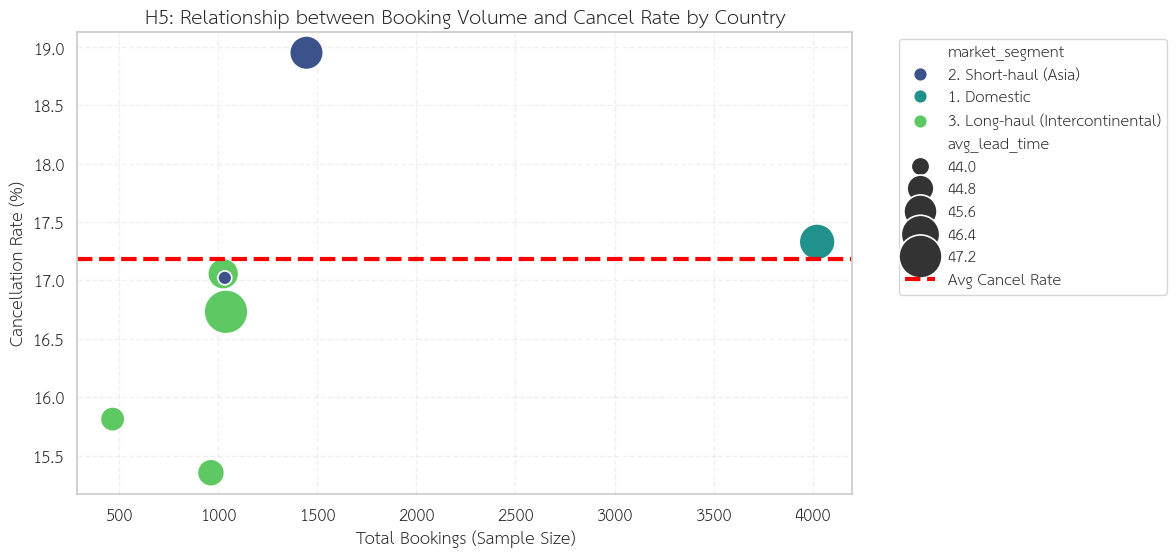

สถิติรายประเทศ:


,country_of_origin,market_segment,total_bookings,cancel_rate,avg_lead_time
1,China,2. Short-haul (Asia),1446,18.95,45.67
4,Thailand,1. Domestic,4022,17.33,46.01
5,UK,3. Long-haul (Intercontinental),1026,17.06,45.30
3,Japan,2. Short-haul (Asia),1034,17.02,43.68
6,USA,3. Long-haul (Intercontinental),1040,16.73,47.35
0,Australia,3. Long-haul (Intercontinental),468,15.81,44.55
2,Germany,3. Long-haul (Intercontinental),964,15.35,44.83


--- H5.1: Top 10 Deadly Combinations (กลุ่มเสี่ยงสูง) ---


,market_segment,channel_name,policy_name,total_bookings,cancel_rate
22,2. Short-haul (Asia),Expedia,Fully Flexible (24h),347,38.04
1,1. Domestic,Booking.com,Fully Flexible (24h),582,36.08
10,1. Domestic,Expedia,Fully Flexible (24h),602,33.55
13,2. Short-haul (Asia),Booking.com,Fully Flexible (24h),346,30.64
19,2. Short-haul (Asia),Direct Website,Fully Flexible (24h),454,19.16
15,2. Short-haul (Asia),Corporate Agent,48 Hour Cancellation,39,17.95
9,1. Domestic,Expedia,48 Hour Cancellation,158,17.09
7,1. Domestic,Direct Website,Fully Flexible (24h),742,16.44
21,2. Short-haul (Asia),Expedia,48 Hour Cancellation,100,16.00
0,1. Domestic,Booking.com,48 Hour Cancellation,153,15.69



--- H5.2: ประสิทธิภาพรายช่องทาง (Channel Insights) ---

══════════════════════════════════════════════════════════════════════
║ CHANNEL NAME         │     TOTAL BOOKINGS │     CANCEL RATE ║
╟──────────────────────┼────────────────────┼─────────────────╢
║ Expedia              │              2,316 │          25.00% ║
║ Booking.com          │              2,252 │          23.89% ║
║ Direct Website       │              2,708 │          14.29% ║
║ Corporate Agent      │              2,724 │           7.86% ║
══════════════════════════════════════════════════════════════════════


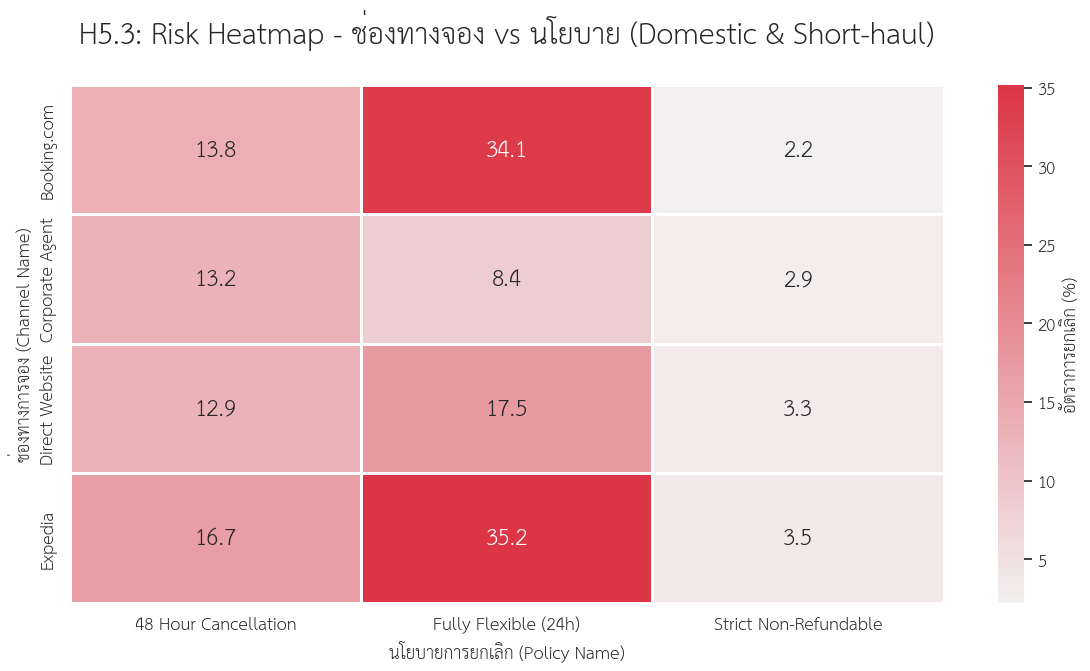

=== สรุปความแตกต่างทางพฤติกรรมตาม Market Segment ===


,market_segment,avg_lead_time,std_lead_time,flexible_booking_ratio,avg_true_loss
0,1. Domestic,46.01,45.74,72.35,"3,031.61"
1,2. Short-haul (Asia),44.84,44.06,70.77,"3,252.91"
2,3. Long-haul (Intercontinental),45.68,44.06,71.21,"2,850.76"


In [31]:
# ==============================================================================
# H5: Standardized Geography & Market Segment Analysis
# ==============================================================================

# 1. สร้าง Dictionary สำหรับจัดกลุ่มให้เป็นมาตรฐานเดียวกันทั้งโปรเจกต์
market_mapping = {
    'Thailand': '1. Domestic',
    'China': '2. Short-haul (Asia)',
    'Japan': '2. Short-haul (Asia)',
    'Australia': '3. Long-haul (Intercontinental)', # ออสเตรเลียจัดเป็น Long-haul หรือ Mid-haul ก็ได้
    'USA': '3. Long-haul (Intercontinental)',
    'UK': '3. Long-haul (Intercontinental)',
    'Germany': '3. Long-haul (Intercontinental)'
}

# สร้างคอลัมน์ใหม่ ชื่อ market_segment
df['market_segment'] = df['country_of_origin'].map(market_mapping)

# 2. ดูภาพรวมพฤติกรรมตามกลุ่ม Market Segment ที่จัดใหม่
segment_stats = df.groupby('market_segment').agg(
    total_bookings=('booking_id', 'count'),
    cancel_rate=('status', lambda x: (x == 'Cancelled').mean() * 100),
    avg_lead_time=('lead_time', 'mean'),
    avg_true_loss=('true_expected_loss', 'mean')
).round(2)

print("--- ภาพรวมพฤติกรรมตาม Market Segment ---")
display(segment_stats)

# --- [จุดที่แก้ที่ 1]: สร้าง h5_stats ให้มีคอลัมน์ market_segment เพื่อเอาไปใช้ทำสี (hue) ในกราฟ ---
h5_stats = df.groupby(['country_of_origin', 'market_segment']).agg(
    total_bookings=('booking_id', 'count'),
    cancel_rate=('status', lambda x: (x == 'Cancelled').mean() * 100),
    avg_lead_time=('lead_time', 'mean')
).reset_index().sort_values('cancel_rate', ascending=False)

# 3. วาดกราฟเปรียบเทียบแบบเห็นจำนวน Booking ด้วย (Bubble Chart หรือ Scatter)
plt.figure(figsize=(10, 6))
# --- [จุดที่แก้ที่ 2]: เปลี่ยน hue=h5_stats.index เป็น hue='market_segment' ---
sns.scatterplot(data=h5_stats, x='total_bookings', y='cancel_rate', size='avg_lead_time',
                hue='market_segment', sizes=(100, 1000), palette='viridis', legend=True)

# ใส่เส้นค่าเฉลี่ยรวมเพื่อเปรียบเทียบ
plt.axhline(df[df['status']=='Cancelled'].shape[0]/df.shape[0]*100, color='red', linestyle='--', label='Avg Cancel Rate')

plt.title('H5: Relationship between Booking Volume and Cancel Rate by Country', fontsize=14, weight='bold')
plt.xlabel('Total Bookings (Sample Size)')
plt.ylabel('Cancellation Rate (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print("สถิติรายประเทศ:")
display(h5_stats)

# ==============================================================================
# H5: วิเคราะห์จุดรั่วไหล - ความสัมพันธ์ระหว่าง ช่องทาง (Channel) และ นโยบาย (Policy)
# ==============================================================================

# 1. H5.1: Top 10 Deadly Combinations (High Risk Group)
# ------------------------------------------------------------------------------
# --- [จุดที่แก้ที่ 3]: เปลี่ยนการ groupby จาก 'country_of_origin' เป็น 'market_segment' ---
deadly_combos = df.groupby(['market_segment', 'channel_name', 'policy_name'], observed=False).agg(
    total_bookings=('booking_id', 'count'),
    cancel_rate=('status', lambda x: (x == 'Cancelled').mean() * 100)
).reset_index()

# กรองเฉพาะกลุ่มเสี่ยงที่เราสนใจ
# --- [จุดที่แก้ที่ 4]: เปลี่ยนจากการระบุชื่อประเทศ เป็นระบุกลุ่ม Segment ---
target_segments = ['1. Domestic', '2. Short-haul (Asia)']
target_risks = deadly_combos[deadly_combos['market_segment'].isin(target_segments)]
target_risks = target_risks.sort_values('cancel_rate', ascending=False).head(10)

print("--- H5.1: Top 10 Deadly Combinations (กลุ่มเสี่ยงสูง) ---")
display(target_risks)

# 2. H5.2: Channel Performance (Cancellation Source)
# ------------------------------------------------------------------------------
channel_stats = df.groupby('channel_name', observed=False).agg(
    total_bookings=('booking_id', 'count'),
    cancel_rate=('status', lambda x: (x == 'Cancelled').mean() * 100)
).sort_values('cancel_rate', ascending=False)

print("\n--- H5.2: ประสิทธิภาพรายช่องทาง (Channel Insights) ---")
# สรุปตารางสรุปแบบเนี๊ยบๆ
print("\n" + "═"*70)
print(f"║ {'CHANNEL NAME':<20} │ {'TOTAL BOOKINGS':>18} │ {'CANCEL RATE':>15} ║")
print("╟" + "─"*22 + "┼" + "─"*20 + "┼" + "─"*17 + "╢")
for idx, row in channel_stats.iterrows():
    # ไฮไลท์สีแดงถ้าอัตราการยกเลิกสูงเกิน 20%
    color_start = "\033[91m" if row['cancel_rate'] > 20 else ""
    print(f"║ {color_start}{idx:<20}\033[0m │ {row['total_bookings']:>18,.0f} │ {row['cancel_rate']:>14.2f}% ║")
print("═"*70)

# 3. H5.3: Risk Heatmap (Red to White Tone)
# ------------------------------------------------------------------------------
# --- [จุดที่แก้ที่ 5]: ใช้ target_segments มากองข้อมูลแทนประเทศ ---
pivot_table = df[df['market_segment'].isin(target_segments)].pivot_table(
    index='channel_name',
    columns='policy_name',
    values='status',
    aggfunc=lambda x: (x == 'Cancelled').mean() * 100
)

plt.figure(figsize=(12, 7))

# ใช้ C_RED ไล่จาก ขาว -> แดงเข้ม เพื่อเน้นจุดที่ "รั่วไหล" จริงๆ
cmap = sns.light_palette(C_RED, as_cmap=True)

ax = sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'อัตราการยกเลิก (%)'}
)

# เปลี่ยนชื่อแกนเล็กน้อยให้ตรงกับกลุ่ม
plt.title('H5.3: Risk Heatmap - ช่องทางจอง vs นโยบาย (Domestic & Short-haul)', weight='bold', pad=30)
plt.xlabel('นโยบายการยกเลิก (Policy Name)', weight='bold')
plt.ylabel('ช่องทางการจอง (Channel Name)', weight='bold')

plt.tight_layout()
plt.show()

# 4. เปรียบเทียบความแน่นอน (SD) และความเสี่ยงจริง
# --- [จุดที่แก้ที่ 6]: ไม่ต้องใช้ np.where สุ่มกลุ่มแล้ว ใช้ market_segment ที่สร้างไว้จัดกลุ่มเลย ---
final_insight = df.groupby('market_segment', observed=False).agg(
    avg_lead_time=('lead_time', 'mean'),
    std_lead_time=('lead_time', 'std'), # ดูความผันผวน
    flexible_booking_ratio=('policy_name', lambda x: (x == 'Fully Flexible (24h)').mean() * 100),
    avg_true_loss=('true_expected_loss', 'mean')
).reset_index()

print("=== สรุปความแตกต่างทางพฤติกรรมตาม Market Segment ===")
display(final_insight.round(2))

### H6: การยกเลิกส่วนใหญ่มักเกิดขึ้นซ้ำๆจากลูกค้ากลุ่มเดิมๆ (Serial Cancellers)

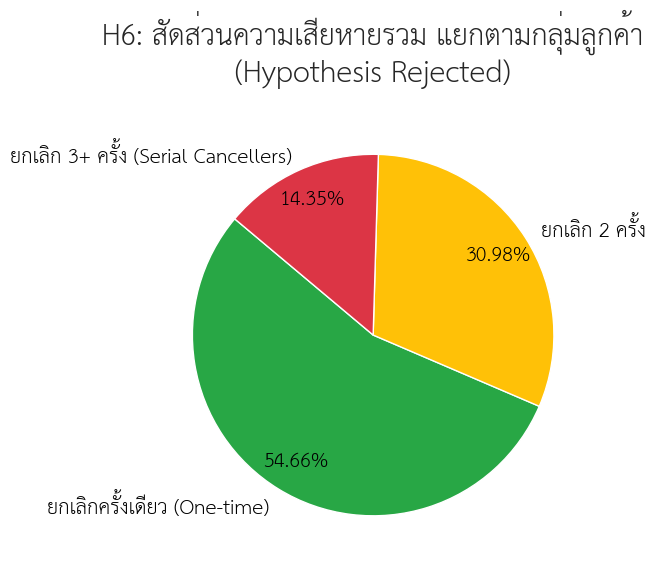

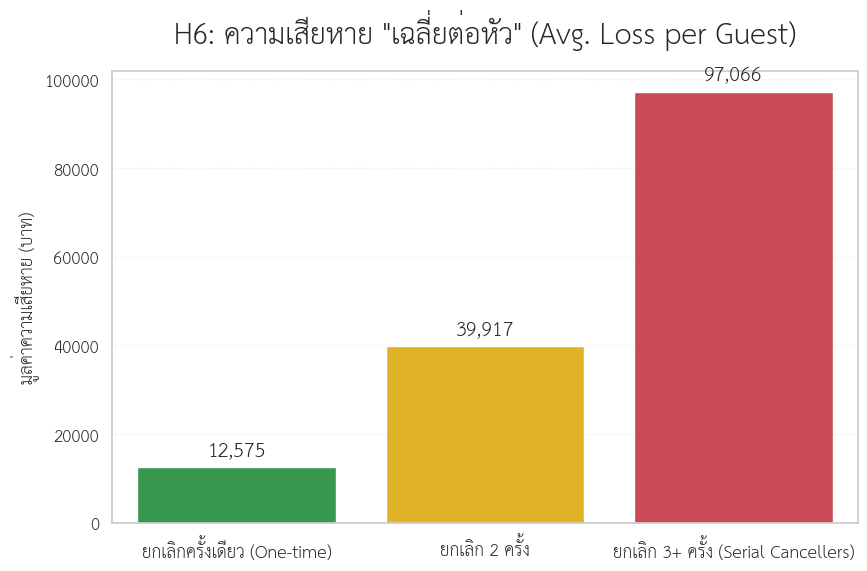

=== สรุปข้อมูล H6 ===


,canceller_type,total_guests,total_financial_loss,avg_loss_per_guest
2,ยกเลิกครั้งเดียว (One-time),1176,"14,788,786.50","12,575.50"
0,ยกเลิก 2 ครั้ง,210,"8,382,681.50","39,917.53"
1,ยกเลิก 3+ ครั้ง (Serial Cancellers),40,"3,882,653.00","97,066.32"


In [32]:
# ==============================================================================
# H6: The Truth about Serial Cancellers (Hypothesis Rejected)
# ==============================================================================

# 1. รวมข้อมูลรายคน (ดึงจาก df หลัก และใช้ true_expected_loss)
guest_loss = df[df['status'] == 'Cancelled'].groupby('guest_id').agg(
    cancel_count=('booking_id', 'count'),
    total_loss=('true_expected_loss', 'sum') # เปลี่ยนเป็น true_expected_loss
).reset_index()

# 2. จัดกลุ่มคนยกเลิก (1 ครั้ง vs ซ้ำซาก)
def group_cancellers(count):
    if count == 1: return 'ยกเลิกครั้งเดียว (One-time)'
    elif count == 2: return 'ยกเลิก 2 ครั้ง'
    else: return 'ยกเลิก 3+ ครั้ง (Serial Cancellers)'

guest_loss['canceller_type'] = guest_loss['cancel_count'].apply(group_cancellers)

# 3. คำนวณสถิติภาพรวม
h6_summary = guest_loss.groupby('canceller_type').agg(
    total_guests=('guest_id', 'count'),
    total_financial_loss=('total_loss', 'sum'),
    avg_loss_per_guest=('total_loss', 'mean')
).reset_index()

# เรียงลำดับเพื่อให้กราฟสวย
h6_summary['sort_order'] = h6_summary['canceller_type'].map({
    'ยกเลิกครั้งเดียว (One-time)': 1,
    'ยกเลิก 2 ครั้ง': 2,
    'ยกเลิก 3+ ครั้ง (Serial Cancellers)': 3
})
h6_summary = h6_summary.sort_values('sort_order')

# =========================================================
# 4. วาดกราฟ (แยกออกเป็น 2 รูปภาพอิสระจากกัน)
# =========================================================

# กำหนดสีเฉพาะสำหรับกราฟนี้ให้สอดคล้องกับความรุนแรง
colors_pie = [C_BLUE, C_PINK, C_RED]

# ---------------------------------------------------------
# กราฟที่ 1: Pie Chart (สัดส่วนความเสียหายรวม)
# ---------------------------------------------------------
plt.figure(figsize=(9, 6)) # ปรับขนาดรูปเดี่ยวให้พอดี
wedges, texts, autotexts = plt.pie(
    h6_summary['total_financial_loss'],
    labels=h6_summary['canceller_type'],
    colors=colors_pie,
    wedgeprops={'edgecolor': 'white'},
    **PIE_PROPS
)
plt.title('H6: สัดส่วนความเสียหายรวม แยกตามกลุ่มลูกค้า\n(Hypothesis Rejected)', weight='bold', pad=20)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# กราฟที่ 2: Bar Chart (ความเสียหายเฉลี่ยต่อหัว)
# ---------------------------------------------------------
plt.figure(figsize=(9, 6)) # ปรับขนาดรูปเดี่ยวให้พอดี

# แก้ Warning: ใช้ x ส่งไปที่ hue ด้วย และปิด legend ทิ้ง (dodge=False ป้องกันกราฟเบี้ยว)
ax = sns.barplot(
    data=h6_summary,
    x='canceller_type',
    y='avg_loss_per_guest',
    hue='canceller_type',
    palette=colors_pie,
    dodge=False
)
plt.legend([], [], frameon=False) # ซ่อน Legend ที่งอกมาจากคำสั่ง hue

plt.title('H6: ความเสียหาย "เฉลี่ยต่อหัว" (Avg. Loss per Guest)', weight='bold', pad=20)
plt.ylabel('มูลค่าความเสียหาย (บาท)')
plt.xlabel('')

# ใส่ตัวเลขกำกับบนแท่งกราฟ
for p in ax.patches:
    height = p.get_height()
    # ดักจับค่าว่างกรณีใช้ hue แล้วเกิดแท่งกราฟล่องหน
    if pd.isna(height) or height == 0:
        continue
    ax.annotate(f"{int(height):,}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=14, weight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. แสดงตารางสรุปผล
# ---------------------------------------------------------
print("=== สรุปข้อมูล H6 ===")
display(h6_summary[['canceller_type', 'total_guests', 'total_financial_loss', 'avg_loss_per_guest']].round(2))

### H7: ยิ่งจองล่วงหน้านาน (Long Lead Time) โอกาสยกเลิกยิ่งสูง และมักจะกดยกเลิกใกล้กับวันเข้าพัก

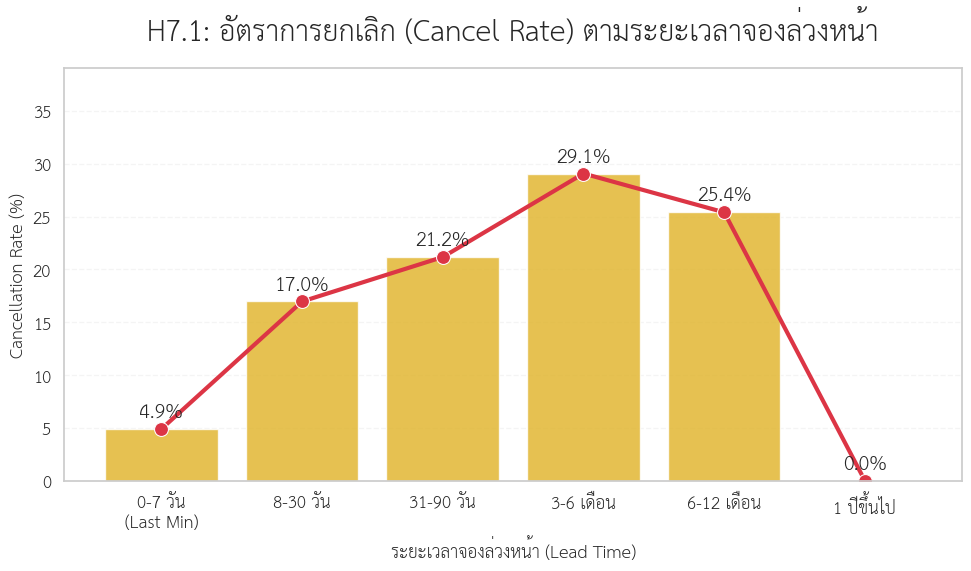

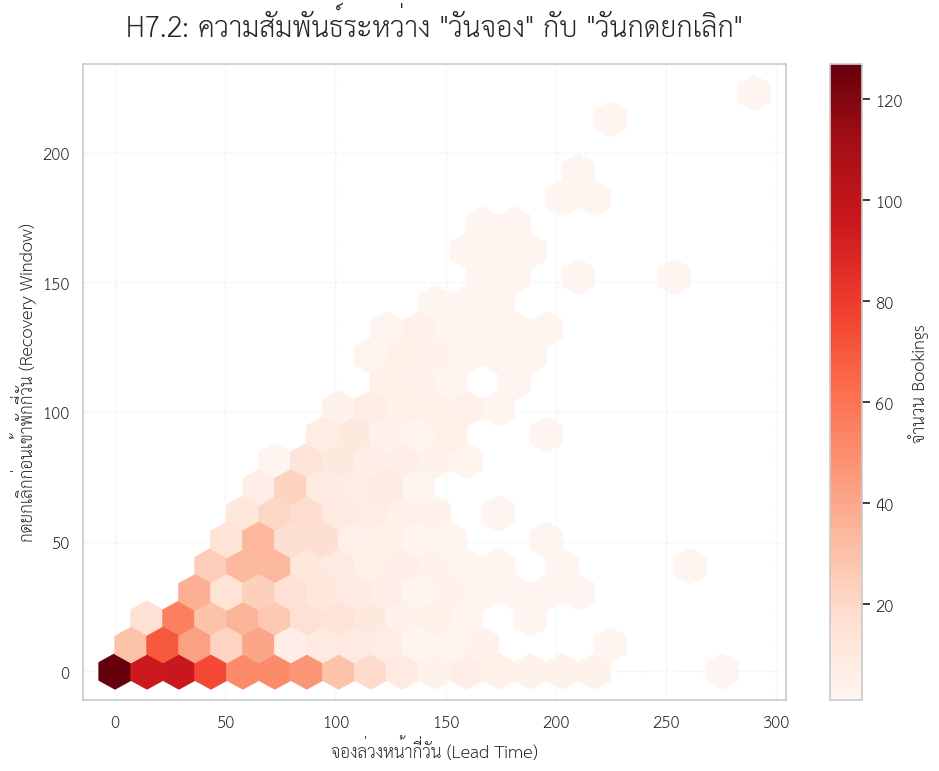

=== สรุปอัตราการยกเลิกตาม Lead Time ===


,lead_time_group,total_bookings,cancel_rate
0,0-7 วัน\n(Last Min),2679,4.89
1,8-30 วัน,1828,16.96
2,31-90 วัน,3983,21.16
3,3-6 เดือน,1383,29.07
4,6-12 เดือน,126,25.40
5,1 ปีขึ้นไป,1,0.00


In [33]:
# ==============================================================================
# H7: Lead Time & Last-Minute Cancellation Impact (แบบแยกรูป)
# ==============================================================================

# 1. กรองเฉพาะข้อมูลที่ยกเลิก จาก df หลัก
cancels = df[df['status'] == 'Cancelled'].copy()

# 2. คำนวณ Cancellation Rate ตามช่วงเวลาจองล่วงหน้า (ใช้ lead_time_group จาก df)
lead_time_stats = df.groupby('lead_time_group', observed=False).agg(
    total_bookings=('booking_id', 'count'),
    cancel_rate=('status', lambda x: (x == 'Cancelled').mean() * 100)
).reset_index()

# =========================================================
# กราฟรูปที่ 1: ยิ่งจองนาน ยิ่งยกเลิกเยอะจริงไหม?
# =========================================================
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=lead_time_stats, x='lead_time_group', y='cancel_rate', color=C_PINK, alpha=0.8)
sns.lineplot(data=lead_time_stats, x='lead_time_group', y='cancel_rate', color=C_RED, marker='o', markersize=10, linewidth=3, ax=ax1)

plt.title('H7.1: อัตราการยกเลิก (Cancel Rate) ตามระยะเวลาจองล่วงหน้า', weight='bold', pad=20)
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('ระยะเวลาจองล่วงหน้า (Lead Time)')
plt.ylim(0, max(lead_time_stats['cancel_rate']) + 10)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=14, weight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# =========================================================
# กราฟรูปที่ 2: Hexbin Plot (เปลี่ยนแกน Y มาใช้ recovery_days)
# =========================================================
plt.figure(figsize=(10, 8))

# ใช้ cancels['recovery_days'] แทน cancels['days_before_arrival'] ตัวเก่า
hb = plt.hexbin(cancels['lead_time'], cancels['recovery_days'], gridsize=20, cmap='Reds', mincnt=1)
cb = plt.colorbar(hb, label='จำนวน Bookings')

plt.title('H7.2: ความสัมพันธ์ระหว่าง "วันจอง" กับ "วันกดยกเลิก"', weight='bold', pad=20)
plt.xlabel('จองล่วงหน้ากี่วัน (Lead Time)')
plt.ylabel('กดยกเลิกก่อนเข้าพักกี่วัน (Recovery Window)')

plt.tight_layout()
plt.show()

print("=== สรุปอัตราการยกเลิกตาม Lead Time ===")
display(lead_time_stats)

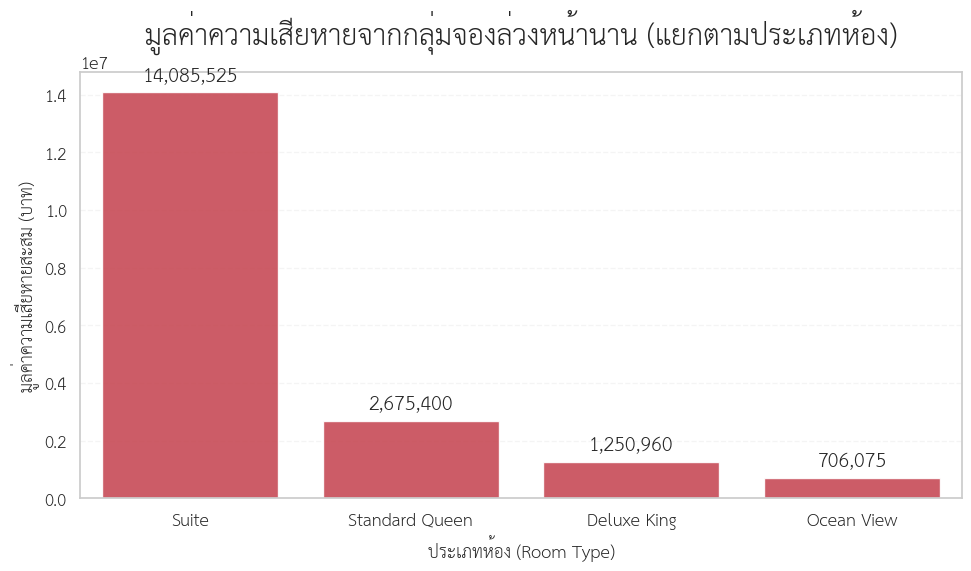

=== สรุปความเสียหายแยกตามประเภทห้อง ===


,room_type_name,cancel_count,total_loss
3,Suite,404,"14,085,525.00"
2,Standard Queen,600,"2,675,400.00"
0,Deluxe King,183,"1,250,960.00"
1,Ocean View,90,"706,075.00"


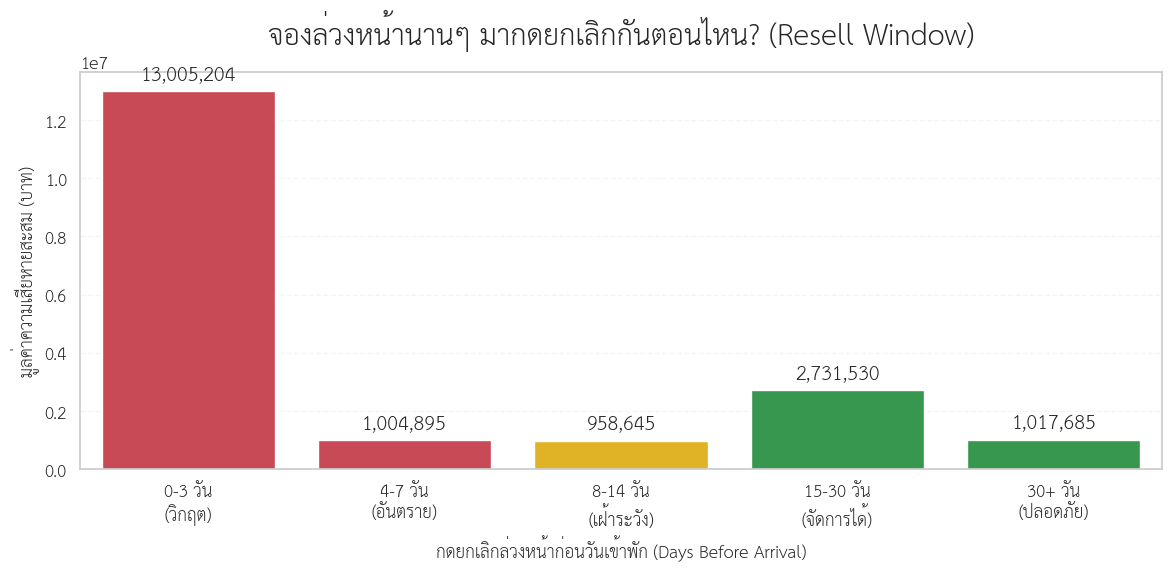


=== สรุปความเสียหายแยกตามช่วงเวลาที่กดยกเลิก ===


,dba_group,cancel_count,total_loss
0,0-3 วัน\n(วิกฤต),320,"13,005,204.50"
1,4-7 วัน\n(อันตราย),61,"1,004,895.50"
2,8-14 วัน\n(เฝ้าระวัง),87,"958,645.00"
3,15-30 วัน\n(จัดการได้),238,"2,731,530.00"
4,30+ วัน\n(ปลอดภัย),571,"1,017,685.00"


In [34]:
## ==============================================================================
# Deep Dive H7: เจาะลึกกลุ่ม Long Lead Time (>30 วัน)
# ==============================================================================

# กรองเฉพาะกลุ่มที่ยกเลิก และจองล่วงหน้านานกว่า 30 วัน (High Risk Group)
long_lead_cancels = df[(df['status'] == 'Cancelled') & (df['lead_time'] > 30)].copy()

# 2. สร้างคอลัมน์ days_before_arrival (ถ้าติดลบให้เป็น 0)
cancels['days_before_arrival'] = (cancels['check_in_date'] - cancels['cancellation_date']).dt.days
cancels['days_before_arrival'] = cancels['days_before_arrival'].clip(lower=0)

# 3. กรองเฉพาะกลุ่มที่ยกเลิก และจองล่วงหน้านานกว่า 30 วัน (High Risk Group)
long_lead_cancels = cancels[cancels['lead_time'] > 30].copy()

# =========================================================
# Q2: Inventory Impact (พวกเขากั๊กห้องประเภทไหนไว้?)
# =========================================================
q2_impact = long_lead_cancels.groupby('room_type_name').agg(
    cancel_count=('booking_id', 'count'),
    total_loss=('true_expected_loss', 'sum')
).reset_index().sort_values('total_loss', ascending=False)

plt.figure(figsize=(10, 6))
# ใช้ C_RED สีเดียวเพื่อเน้นความเสียหาย (แบบนี้ไม่ต้องใช้ hue)
ax1 = sns.barplot(data=q2_impact, x='room_type_name', y='total_loss', color=C_RED, alpha=0.9)
plt.title('มูลค่าความเสียหายจากกลุ่มจองล่วงหน้านาน (แยกตามประเภทห้อง)', weight='bold', pad=20)
plt.ylabel('มูลค่าความเสียหายสะสม (บาท)')
plt.xlabel('ประเภทห้อง (Room Type)')

# ใส่ตัวเลขกำกับ
for p in ax1.patches:
    height = p.get_height()
    if pd.isna(height) or height == 0: continue
    ax1.annotate(f"{int(height):,}", (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=14, weight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("=== สรุปความเสียหายแยกตามประเภทห้อง ===")
display(q2_impact)

# =========================================================
# Q3: The True Danger Zone (เส้นตายของการขายห้องใหม่คือวันไหน?)
# =========================================================
# สร้างช่วงเวลา (Bins) ของวันที่กดยกเลิก
bins_dba = [-1, 3, 7, 14, 30, 9999]
labels_dba = ['0-3 วัน\n(วิกฤต)', '4-7 วัน\n(อันตราย)', '8-14 วัน\n(เฝ้าระวัง)', '15-30 วัน\n(จัดการได้)', '30+ วัน\n(ปลอดภัย)']
long_lead_cancels['dba_group'] = pd.cut(long_lead_cancels['days_before_arrival'], bins=bins_dba, labels=labels_dba)

q3_danger = long_lead_cancels.groupby('dba_group', observed=False).agg(
    cancel_count=('booking_id', 'count'),
    total_loss=('true_expected_loss', 'sum')
).reset_index()

plt.figure(figsize=(12, 6))
# ไล่ระดับสีตามความอันตราย (แดง = วิกฤต, เหลือง = เฝ้าระวัง, เขียว = จัดการได้/ปลอดภัย)
severity_colors = [C_RED, C_RED, C_PINK, C_BLUE, C_BLUE]

# [แก้ไข WARNING] ใส่ hue='dba_group' เข้าไปคู่กับ x และสั่ง dodge=False เพื่อไม่ให้กราฟเบี้ยว
ax2 = sns.barplot(data=q3_danger, x='dba_group', y='total_loss', hue='dba_group', palette=severity_colors, dodge=False)
plt.legend([],[], frameon=False) # ซ่อน Legend ที่เกินมา

plt.title('จองล่วงหน้านานๆ มากดยกเลิกกันตอนไหน? (Resell Window)', weight='bold', pad=20)
plt.ylabel('มูลค่าความเสียหายสะสม (บาท)')
plt.xlabel('กดยกเลิกล่วงหน้าก่อนวันเข้าพัก (Days Before Arrival)')

# ใส่ตัวเลขกำกับ
for p in ax2.patches:
    height = p.get_height()
    if pd.isna(height) or height == 0: continue
    ax2.annotate(f"{int(height):,}", (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=14, weight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n=== สรุปความเสียหายแยกตามช่วงเวลาที่กดยกเลิก ===")
display(q3_danger)

### H8: No-Show มักเกิดขึ้นกระจุกตัวในวันหยุดสุดสัปดาห์ (ศุกร์-อาทิตย์)

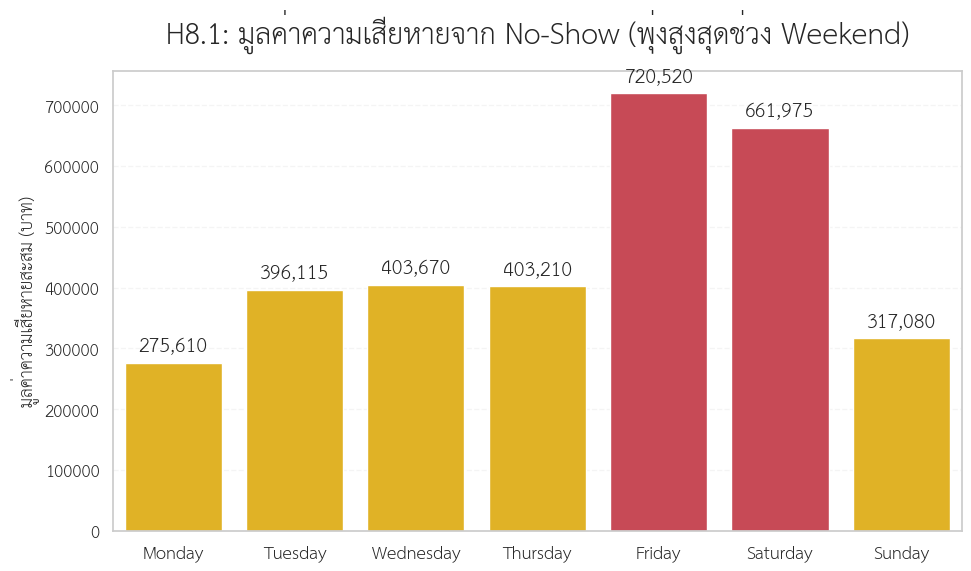

=== H8.2: สัดส่วนการเก็บค่าปรับจากกลุ่ม No-Show ===


,สถานะการเก็บค่าปรับ,จำนวน (Bookings),สัดส่วน (%)
0,เก็บค่าปรับได้ (Penalty Collected),219,100.00



------------------------------------------------------------

=== สรุปความเสียหาย No-Show แยกตามวัน ===


,day_name,total_loss,booking_count
0,Monday,"275,610.00",29
1,Tuesday,"396,115.00",20
2,Wednesday,"403,670.00",21
3,Thursday,"403,210.00",26
4,Friday,"720,520.00",42
5,Saturday,"661,975.00",51
6,Sunday,"317,080.00",30


In [35]:
# ==============================================================================
# H8: Weekend No-Shows Deep Dive (The Invisible Danger)
# ==============================================================================

# 1. กรองเฉพาะข้อมูล No-Show จาก df หลัก
noshows = df[df['status'] == 'No-Show'].copy()

# สร้างคอลัมน์ชื่อวัน
noshows['day_name'] = noshows['check_in_date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
noshows['day_name'] = pd.Categorical(noshows['day_name'], categories=days_order, ordered=True)

# =========================================================
# กราฟรูปที่ 1: มูลค่าความเสียหายจาก No-Show แยกตามวันในสัปดาห์
# =========================================================
h8_loss = noshows.groupby('day_name', observed=False).agg(
    total_loss=('true_expected_loss', 'sum'), # ใช้ true_expected_loss จาก df ได้เลย
    booking_count=('booking_id', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
colors_weekend = [C_PINK if day not in ['Friday', 'Saturday'] else C_RED for day in days_order]

ax1 = sns.barplot(data=h8_loss, x='day_name', y='total_loss', palette=colors_weekend, hue='day_name', dodge=False)
plt.legend([],[], frameon=False)

plt.title('H8.1: มูลค่าความเสียหายจาก No-Show (พุ่งสูงสุดช่วง Weekend)', weight='bold', pad=20)
plt.ylabel('มูลค่าความเสียหายสะสม (บาท)')
plt.xlabel('')

for p in ax1.patches:
    height = p.get_height()
    if pd.isna(height) or height == 0: continue
    ax1.annotate(f"{int(height):,}", (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=14, weight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# =========================================================
# H8.2: ตรวจสอบสถานะการเก็บค่าปรับ No-Show (แบบตาราง)
# =========================================================
# แยกกลุ่มคนที่โดนปรับ vs ไม่โดนปรับ
noshows['penalty_status'] = np.where(noshows['penalty_charged'].fillna(0) > 0,
                                     'เก็บค่าปรับได้ (Penalty Collected)',
                                     'ลอยนวล (0 Penalty)')

h8_penalty = noshows['penalty_status'].value_counts().reset_index()
h8_penalty.columns = ['สถานะการเก็บค่าปรับ', 'จำนวน (Bookings)']
h8_penalty['สัดส่วน (%)'] = (h8_penalty['จำนวน (Bookings)'] / len(noshows) * 100).round(2)

print("=== H8.2: สัดส่วนการเก็บค่าปรับจากกลุ่ม No-Show ===")
display(h8_penalty)

# --- เพิ่มระยะห่างระหว่าง 2 ตาราง ---
print("\n" + "-"*60 + "\n")

# พิมพ์ตารางเพื่อดูตัวเลขดิบ
print("=== สรุปความเสียหาย No-Show แยกตามวัน ===")
display(h8_loss)

In [21]:
# =========================================================
# เจาะลึกความเจ็บปวดจาก No-Show (Killer Numbers)
# =========================================================

# สมมติฐาน: เช็คว่ามีคอลัมน์ length_of_stay หรือไม่ ถ้าไม่มีให้คำนวณจากวัน Check-in / Check-out
if 'length_of_stay' not in noshows.columns:
    noshows['check_out_date'] = pd.to_datetime(noshows['check_out_date']) # ปรับชื่อคอลัมน์ให้ตรงกับ Data จริง
    noshows['length_of_stay'] = (noshows['check_out_date'] - noshows['check_in_date']).dt.days

# --- 1. The Opportunity Cost (จองล่วงหน้านานเกิน 30 วัน แล้ว No-Show) ---
long_lead_noshow = noshows[noshows['lead_time'] > 30]
count_long_lead = len(long_lead_noshow)
loss_long_lead = long_lead_noshow['true_expected_loss'].sum()

print(f"1. มูลค่าที่ถูกแช่แข็ง (Opportunity Cost):")
print(f"มีลูกค้าจองล่วงหน้าเกิน 1 เดือนแล้ว No-Show ถึง {count_long_lead} บุ๊กกิ้ง")
print(f"คิดเป็นมูลค่าที่โรงแรมเสียโอกาสขายให้คนอื่นไปฟรีๆ: {loss_long_lead:,.2f} บาท\n")


# --- 2. The Domino Effect (จองหลายคืนติดกัน แล้ว No-Show) ---
# กรองเฉพาะคนที่จองมากกว่า 1 คืน
multi_night_noshow = noshows[noshows['length_of_stay'] > 1]
count_multi_night = len(multi_night_noshow)
total_lost_nights = multi_night_noshow['length_of_stay'].sum()

print(f"2. หายนะแบบโดมิโน่ (Domino Effect):")
print(f"มีลูกค้าที่จองแบบพักต่อเนื่อง (Multi-night) แล้ว No-Show จำนวน {count_multi_night} บุ๊กกิ้ง")
print(f"ทำให้โรงแรมมี 'ห้องฟันหลอ' ที่ปล่อยว่างไปฟรีๆ รวมกันถึง {int(total_lost_nights)} คืน!")

1. มูลค่าที่ถูกแช่แข็ง (Opportunity Cost):
มีลูกค้าจองล่วงหน้าเกิน 1 เดือนแล้ว No-Show ถึง 116 บุ๊กกิ้ง
คิดเป็นมูลค่าที่โรงแรมเสียโอกาสขายให้คนอื่นไปฟรีๆ: 2,122,370.00 บาท

2. หายนะแบบโดมิโน่ (Domino Effect):
มีลูกค้าที่จองแบบพักต่อเนื่อง (Multi-night) แล้ว No-Show จำนวน 195 บุ๊กกิ้ง
ทำให้โรงแรมมี 'ห้องฟันหลอ' ที่ปล่อยว่างไปฟรีๆ รวมกันถึง 1296 คืน!


/tmp/ipykernel_3590/2409248475.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=adr_analysis, x='adr_tier', y='leakage_rate_pct', palette='Reds')


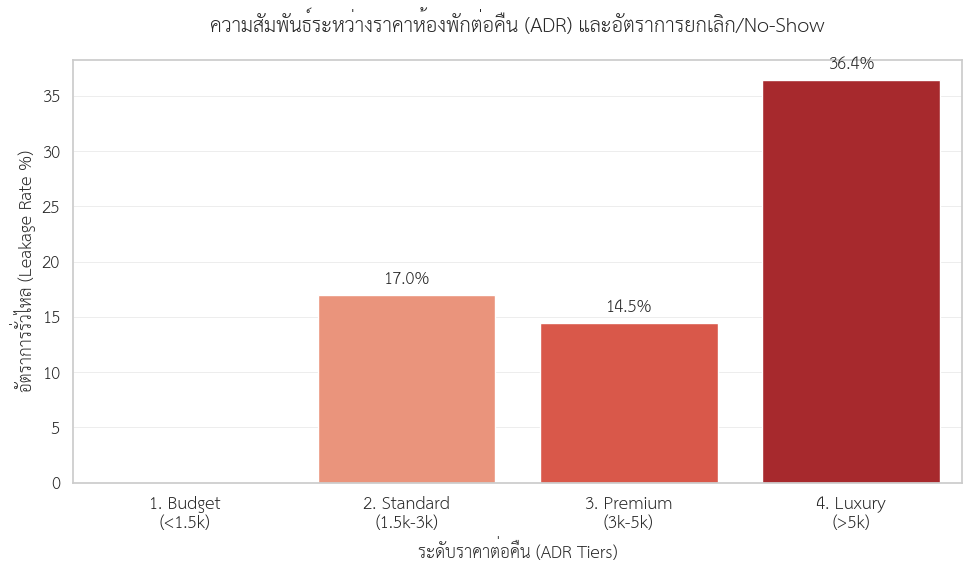


เปรียบเทียบราคา ADR เฉลี่ย แยกตามสถานะการจอง
กลุ่ม Cancelled...... จองมาด้วยราคาเฉลี่ย 3,906 ฿ / คืน
กลุ่ม Checked-In..... จองมาด้วยราคาเฉลี่ย 3,115 ฿ / คืน
กลุ่ม No-Show........ จองมาด้วยราคาเฉลี่ย 3,038 ฿ / คืน


In [40]:
# ==============================================================================
# Extra Analysis: อิทธิพลของราคาต่อคืน (ADR) ที่มีต่อการยกเลิกการจอง
# ==============================================================================

# 1. คำนวณจำนวนคืนเข้าพัก (Length of Stay) และ ราคาต่อคืน (ADR)
df['length_of_stay'] = (df['check_out_date'] - df['check_in_date']).dt.days
df['length_of_stay'] = df['length_of_stay'].replace(0, 1) # ป้องกันหารด้วย 0 (Day-use คิดเป็น 1 คืน)

# คำนวณ ADR (Average Daily Rate)
df['adr'] = df['gross_revenue'] / df['length_of_stay']

# 2. จัดกลุ่มราคา ADR ออกเป็น 4 ระดับ (Tiers)
# (คุณสามารถปรับเลข bins ให้เข้ากับเรทราคาจริงของโรงแรม The Azure Stay ได้)
bins_adr = [0, 1500, 3000, 5000, 99999]
labels_adr = ['1. Budget\n(<1.5k)', '2. Standard\n(1.5k-3k)', '3. Premium\n(3k-5k)', '4. Luxury\n(>5k)']
df['adr_tier'] = pd.cut(df['adr'], bins=bins_adr, labels=labels_adr)

# 3. คำนวณอัตราการรั่วไหล (Leakage Rate) ในแต่ละกลุ่มราคา
adr_analysis = df.groupby('adr_tier', observed=False).agg(
    total_bookings=('booking_id', 'count'),
    leakage_count=('status', lambda x: x.isin(['Cancelled', 'No-Show']).sum())
).reset_index()

# คำนวณเปอร์เซ็นต์
adr_analysis['leakage_rate_pct'] = (adr_analysis['leakage_count'] / adr_analysis['total_bookings']) * 100

# 4. วาดกราฟ: ราคาห้องพักแบบไหนที่เสี่ยงต่อการโดนเทมากที่สุด?
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=adr_analysis, x='adr_tier', y='leakage_rate_pct', palette='Reds')

# จัดการ Grid ให้สวยงาม
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='-', alpha=0.2, linewidth=0.5)

plt.title('ความสัมพันธ์ระหว่างราคาห้องพักต่อคืน (ADR) และอัตราการยกเลิก/No-Show', weight='bold', pad=20, fontsize=14)
plt.ylabel('อัตราการรั่วไหล (Leakage Rate %)')
plt.xlabel('ระดับราคาต่อคืน (ADR Tiers)')

# ใส่ป้าย Label ตัวเลข %
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=12, weight='bold', xytext=(0, 5),
                   textcoords='offset points')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# สถิติเปรียบเทียบ ADR เฉลี่ยของแต่ละกลุ่มสถานะ
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("เปรียบเทียบราคา ADR เฉลี่ย แยกตามสถานะการจอง")
print("="*50)
status_adr = df.groupby('status')['adr'].mean().sort_values(ascending=False)
for status, val in status_adr.items():
    print(f"กลุ่ม {status:.<15} จองมาด้วยราคาเฉลี่ย {val:,.0f} ฿ / คืน")